# Полип в день операции

# Подготовка

## Настройка графики

In [1]:
#windows.options(height=5.4, width=7)
oldpar = par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE);

require(vcd, quietly = TRUE, warn.conflicts = FALSE);
require(coin, quietly = TRUE, warn.conflicts = FALSE);          # independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE);     # HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE);      # kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE);       # for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE);     # numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE);
require(lattice, quietly = TRUE, warn.conflicts = FALSE);
require(mosaic, quietly = TRUE, warn.conflicts = FALSE);
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE);
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE);        # ggqqplot
#require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE);                            # flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE);    # ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE);        # ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE);       # ggparcoord


require(rstatix, quietly = TRUE);                               # identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE);
#require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE);
require(repr, quietly = TRUE, warn.conflicts = FALSE);

require(knitr, quietly = TRUE, warn.conflicts = FALSE);        # Dynamic reports

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2




The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.



Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: 'rstatix'




The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test




The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




The following object is masked from 'package:stats':

    filter




## Данные

### Загрузка

In [3]:
#sessionInfo()
#options(encoding = "UTF-8")
lor = read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\mucous20240825.xlsx", sheet="данные")
# lor = as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
lor = lor %>% 
    dplyr::select("id", "группа", "локация", "этап", "поле", "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                  ) %>%
    filter(локация == "полип") %>%
    filter(этап == 'день операции') %>%
    filter(группа != 'КГ1')
lor = as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа = factor(lor$группа, c("ОГ", "КГ"))

lor$"локация" = factor(lor$"локация")
lor$"этап" = factor(lor$"этап", c("день операции", "6-7 сутки", "1-3 мес.", "1 год"))

#### Медианные значения

In [6]:
lor_mean <- lor %>%
    group_by(id, группа, локация, этап) %>%
    summarise(
        across(c(
                "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                ),
            ~ median(.x, na.rm = TRUE)
        ),
        .groups = "drop"
        # mean_value = mean(measurement_value, na.rm = TRUE),
        # median_value = median(measurement_value, na.rm = TRUE),
        # sd_value = sd(measurement_value, na.rm = TRUE),
        # min_value = min(measurement_value, na.rm = TRUE),
        # max_value = max(measurement_value, na.rm = TRUE)
    ) %>%
    arrange(id) 
# %>%
#     kable(digits = 2)
# lor_mean

### Подключение

In [7]:
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [8]:
groupping_variable = 'группа'

## круглоклеточная воспалительная инфильтрация

### Общее

In [9]:
parname = "круглоклеточная воспалительная инфильтрация"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

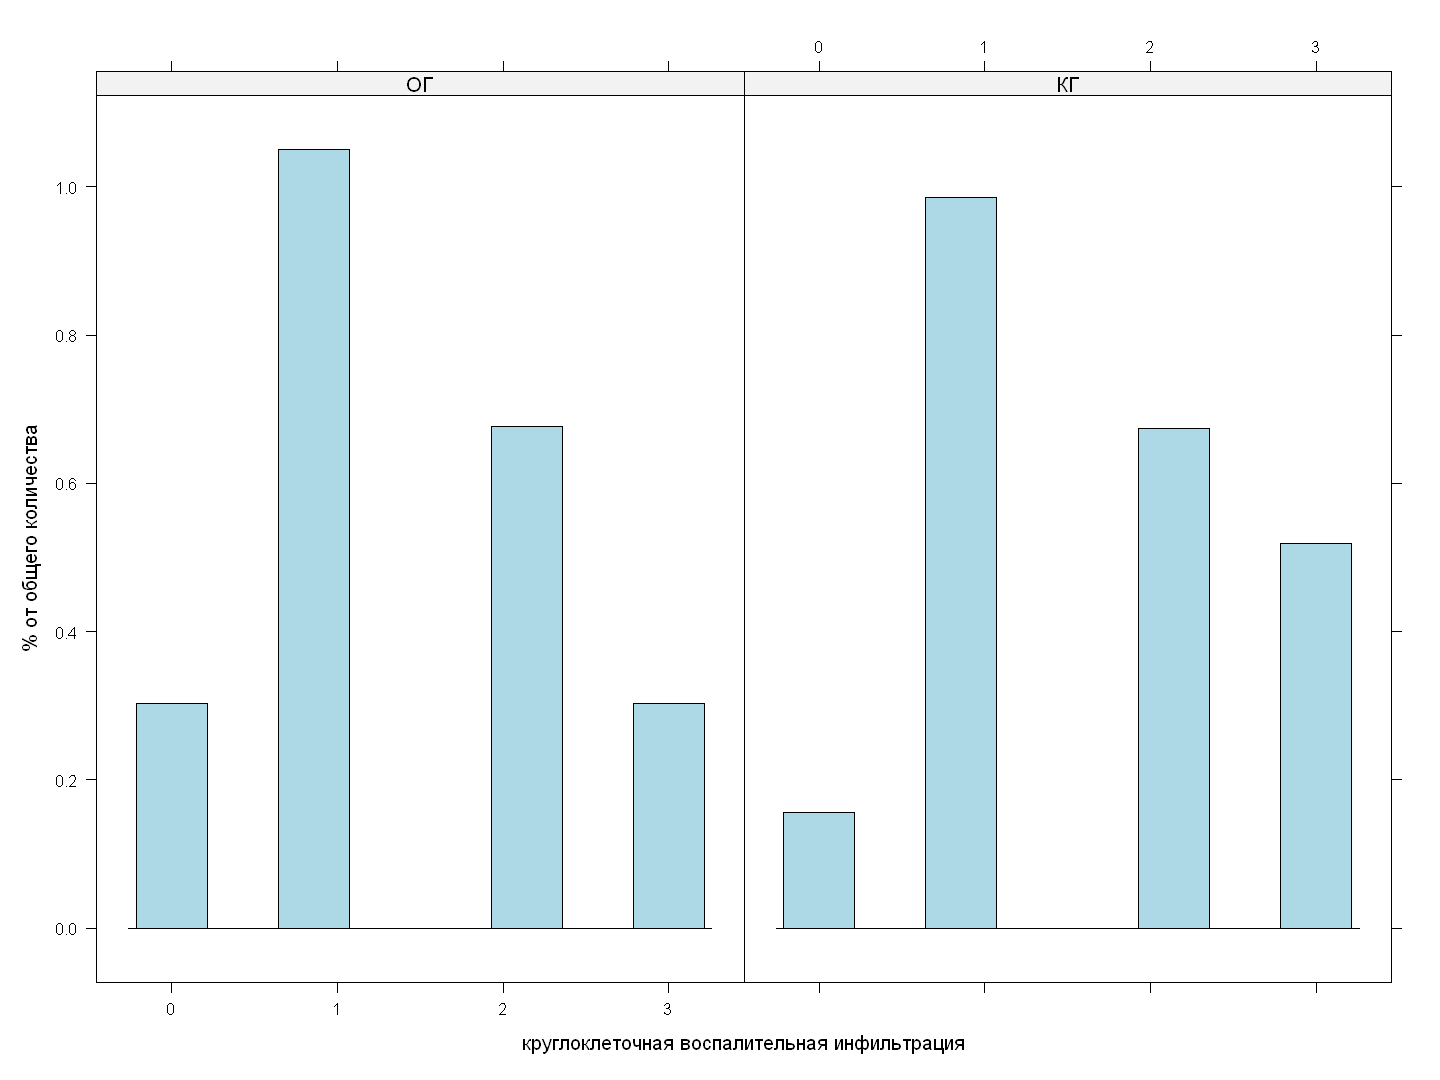

In [10]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [11]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

       mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ 1.420000 0.8782443   1  0   1   1   2    3    100
КГ 1.666667 0.9045340   1  0   1   2   2    3     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,1,1,2,3,1.420000,0.8782443,100,0
КГ,0,1,2,2,3,1.666667,0.9045340,45,0


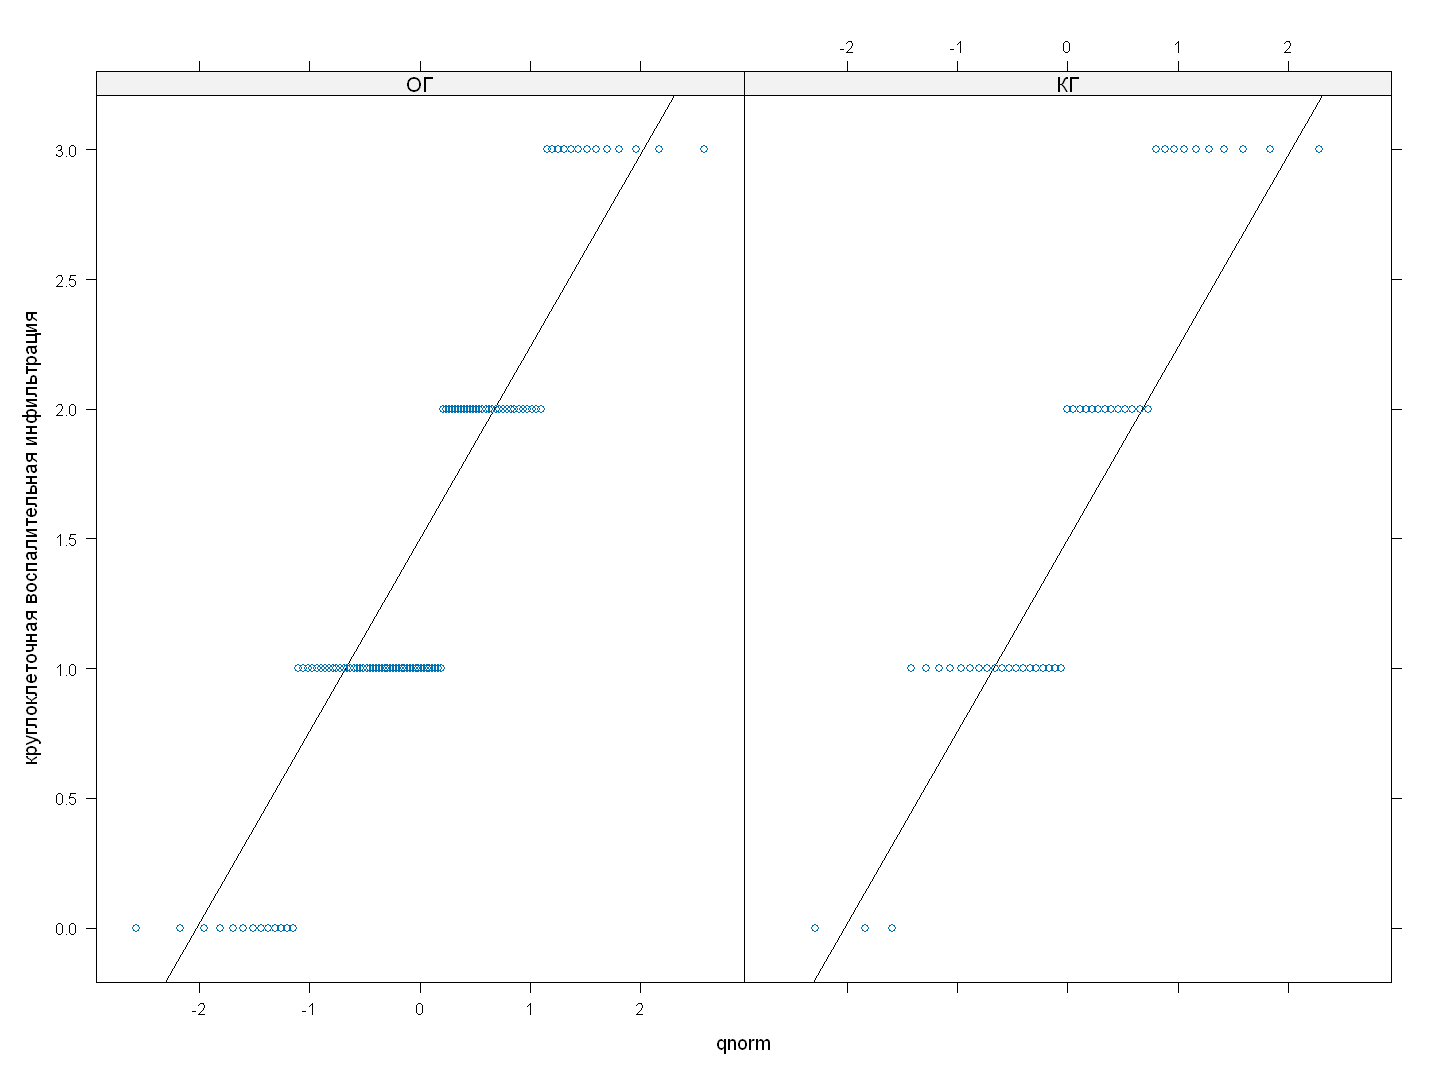

In [12]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

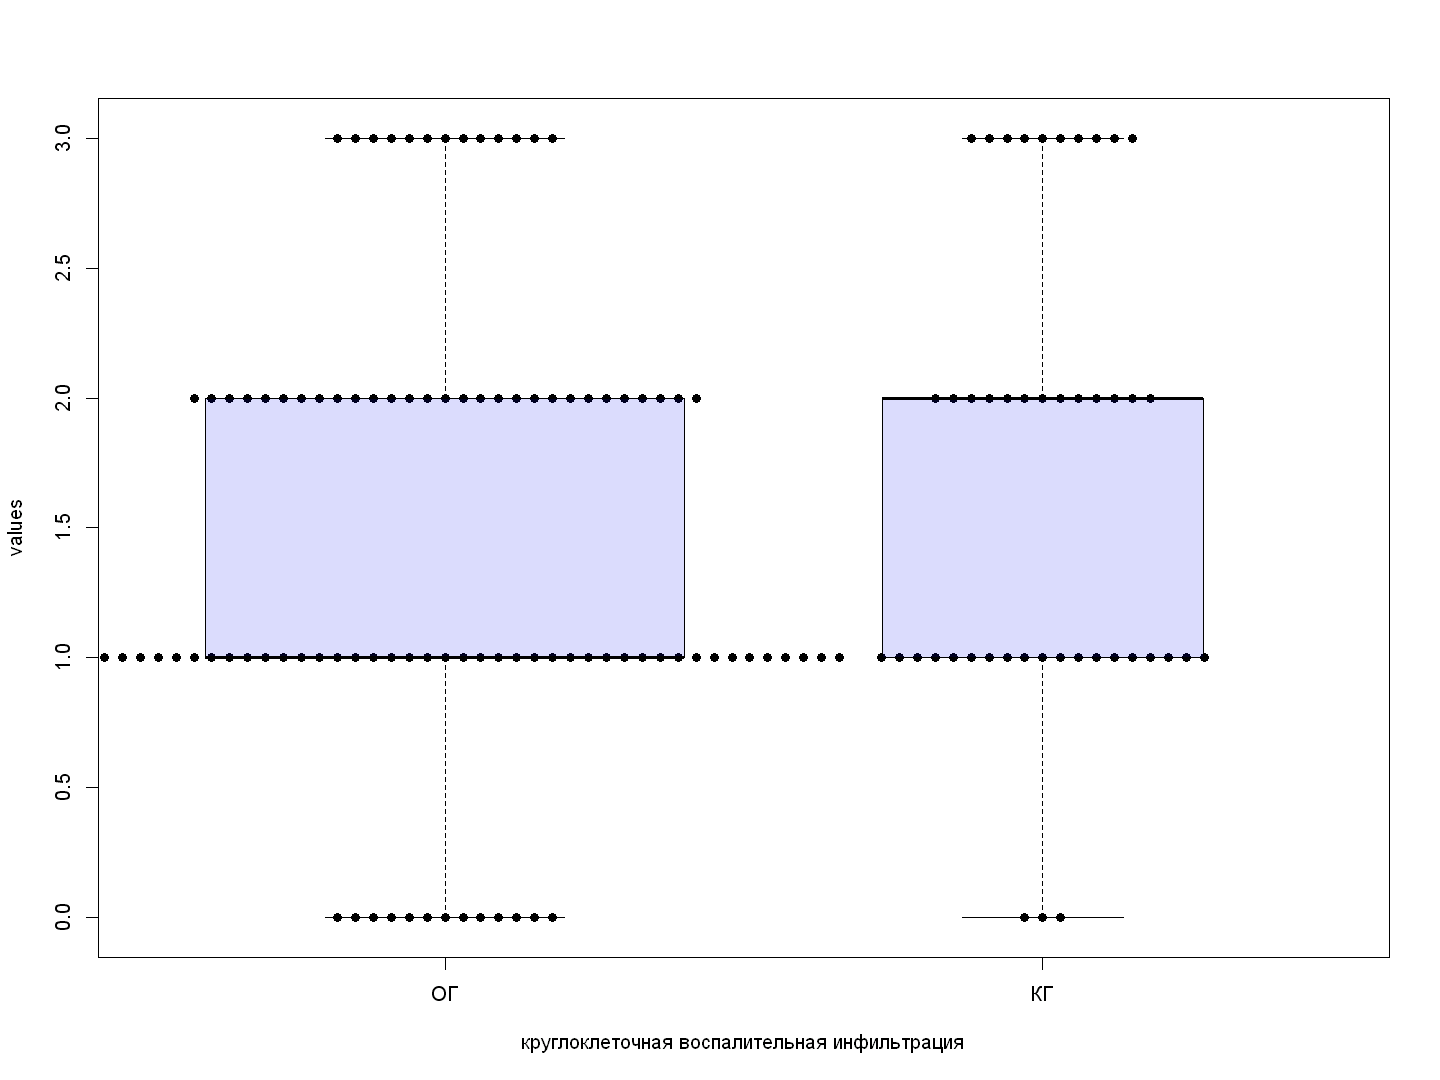

In [13]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [14]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1928.5, p-value = 0.1446
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.461, p-value = 0.144
alternative hypothesis: two.sided


## бокаловидные клетки

### Общее

In [15]:
parname = "бокаловидные клетки"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

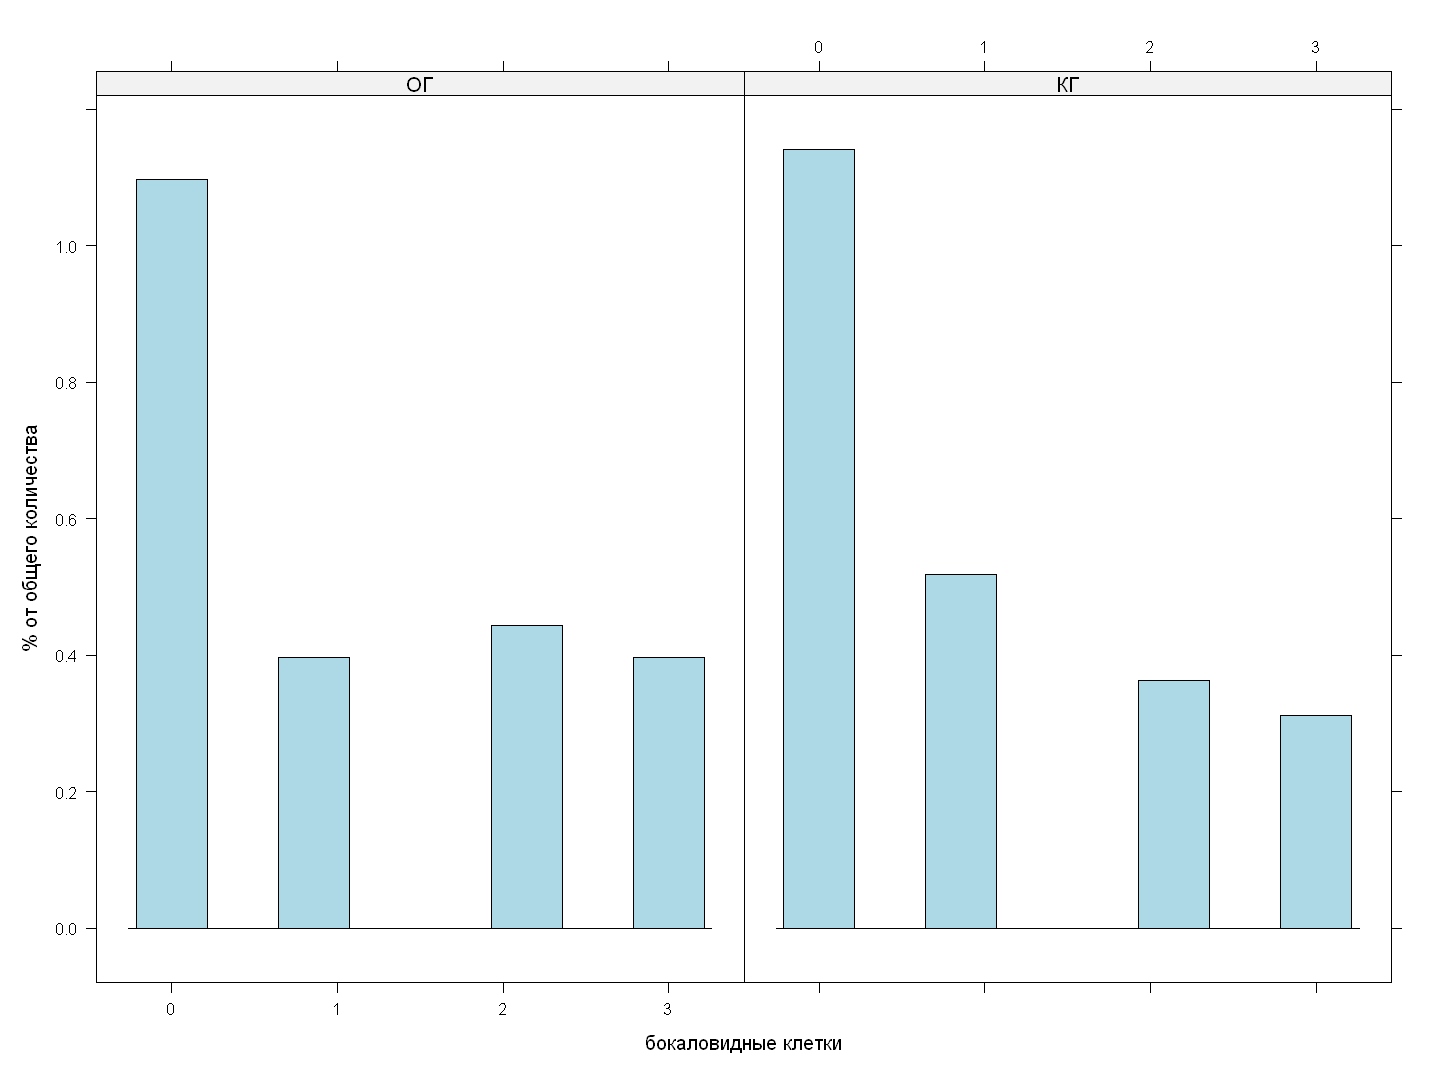

In [16]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [17]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

        mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ 1.0600000 1.161852   2  0   0   1   2    3    100
КГ 0.9333333 1.095445   2  0   0   1   2    3     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,1,2,3,1.0600000,1.161852,100,0
КГ,0,0,1,2,3,0.9333333,1.095445,45,0


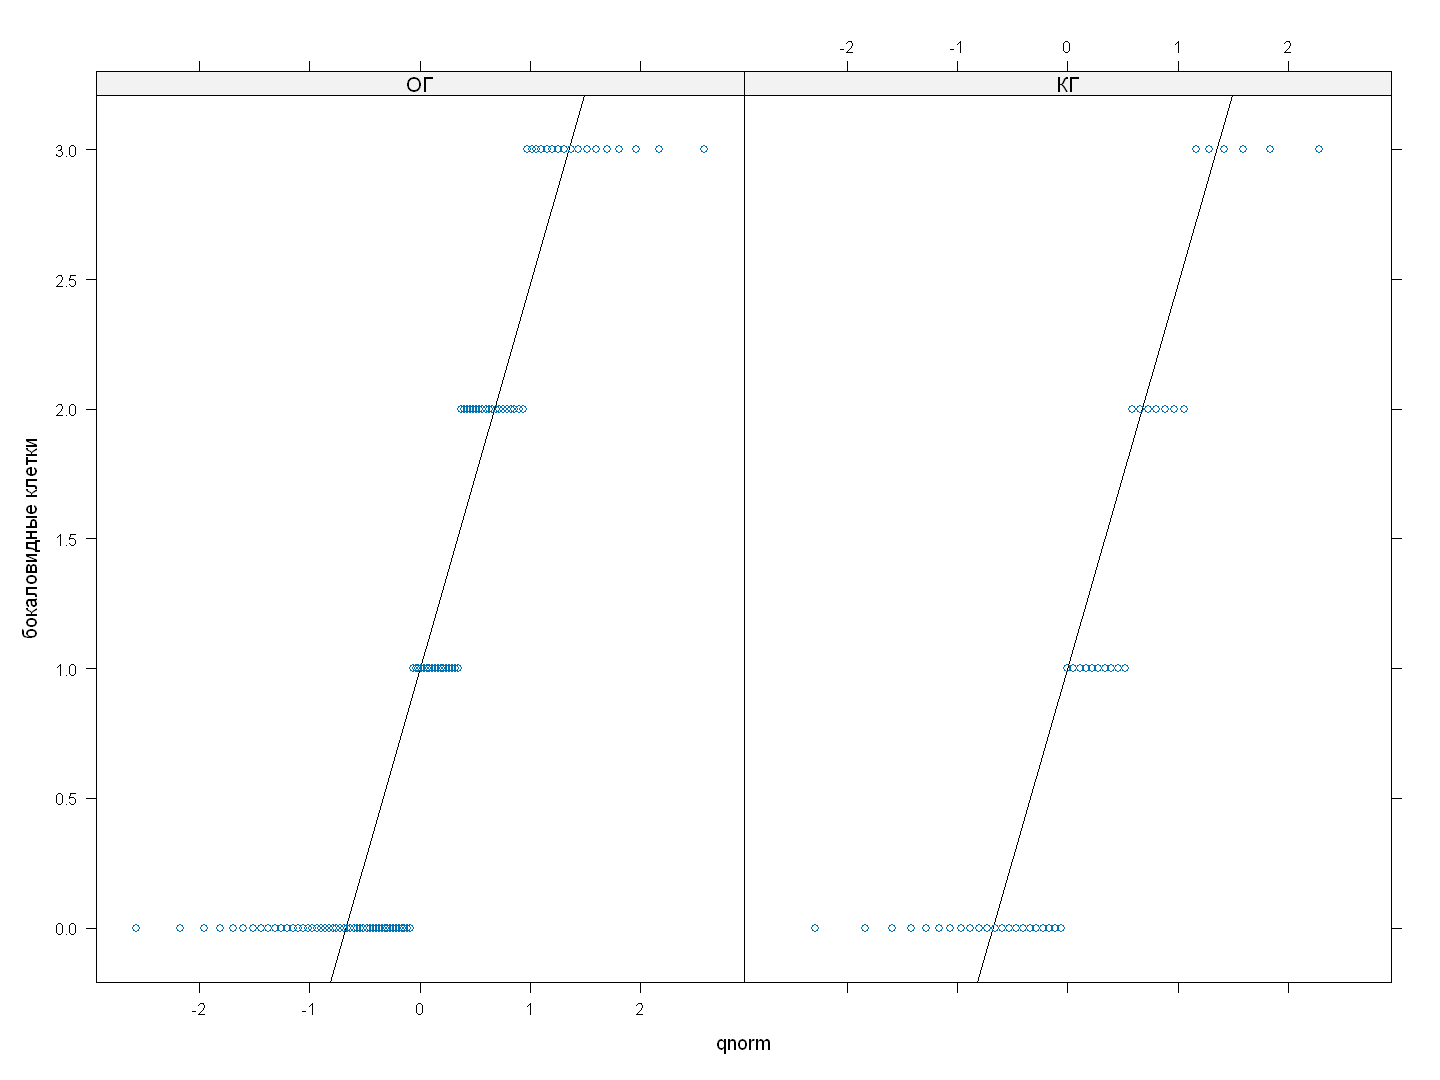

In [18]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

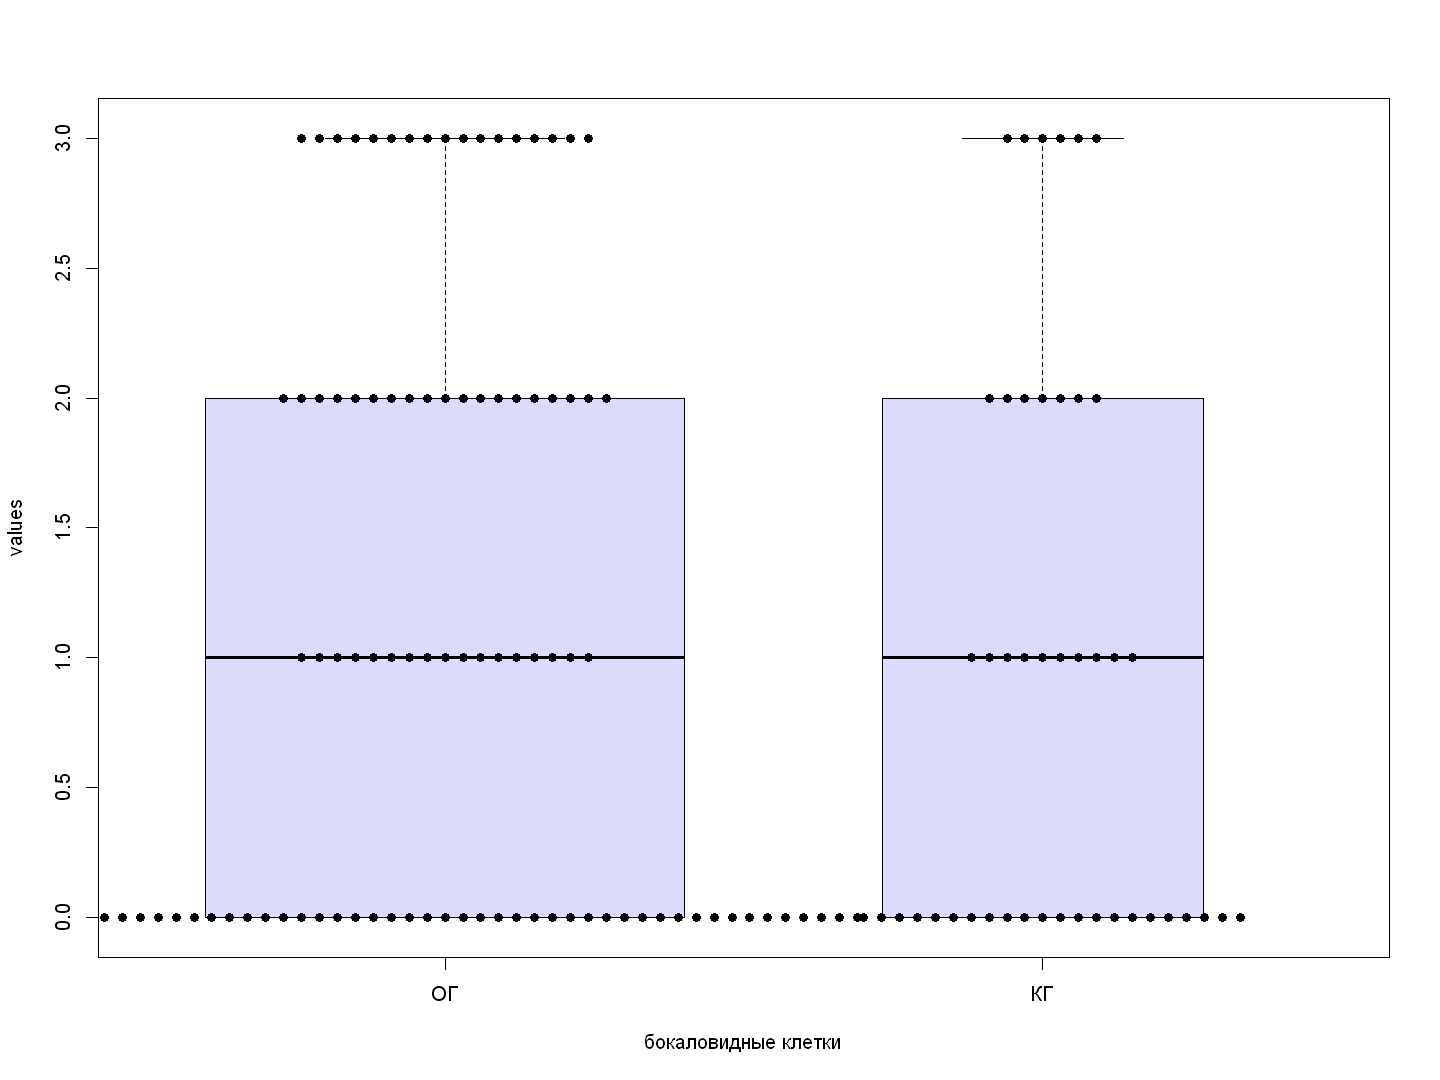

In [19]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [20]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
            )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 2364.5, p-value = 0.6027
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.52281, p-value = 0.6011
alternative hypothesis: two.sided


## отек

### Общее

In [21]:
parname = "отек"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

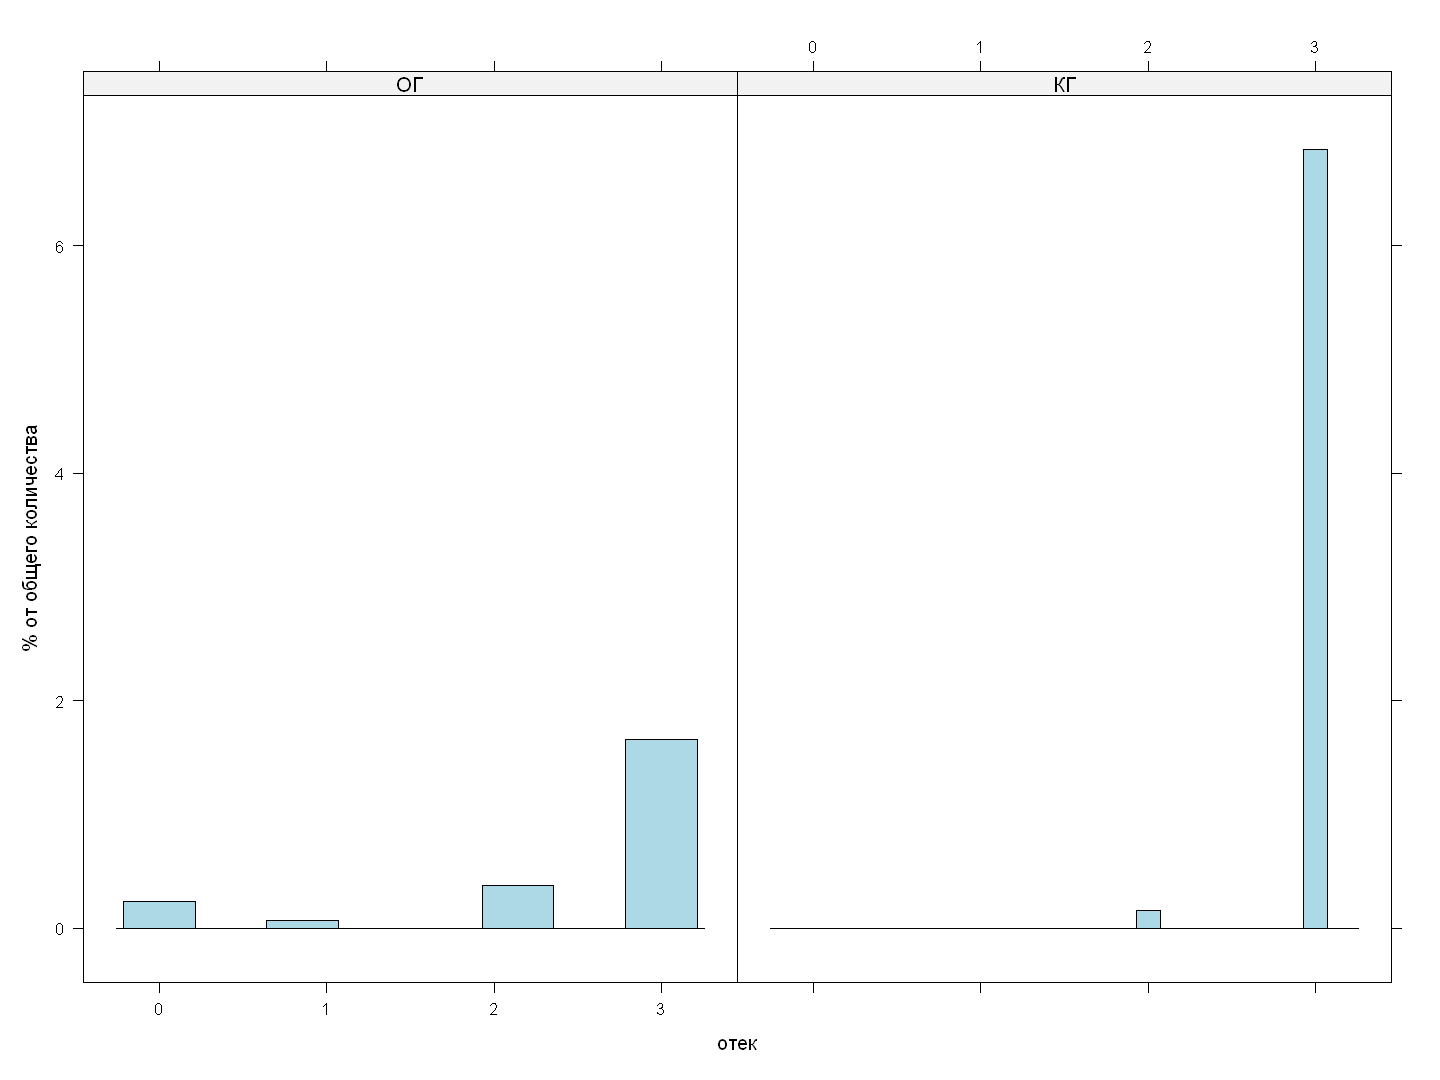

In [22]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [23]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"), 
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

       mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ 2.480000 0.9585342   1  0   2   3   3    3    100
КГ 2.977778 0.1490712   0  2   3   3   3    3     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,2,3,3,3,2.480000,0.9585342,100,0
КГ,2,3,3,3,3,2.977778,0.1490712,45,0


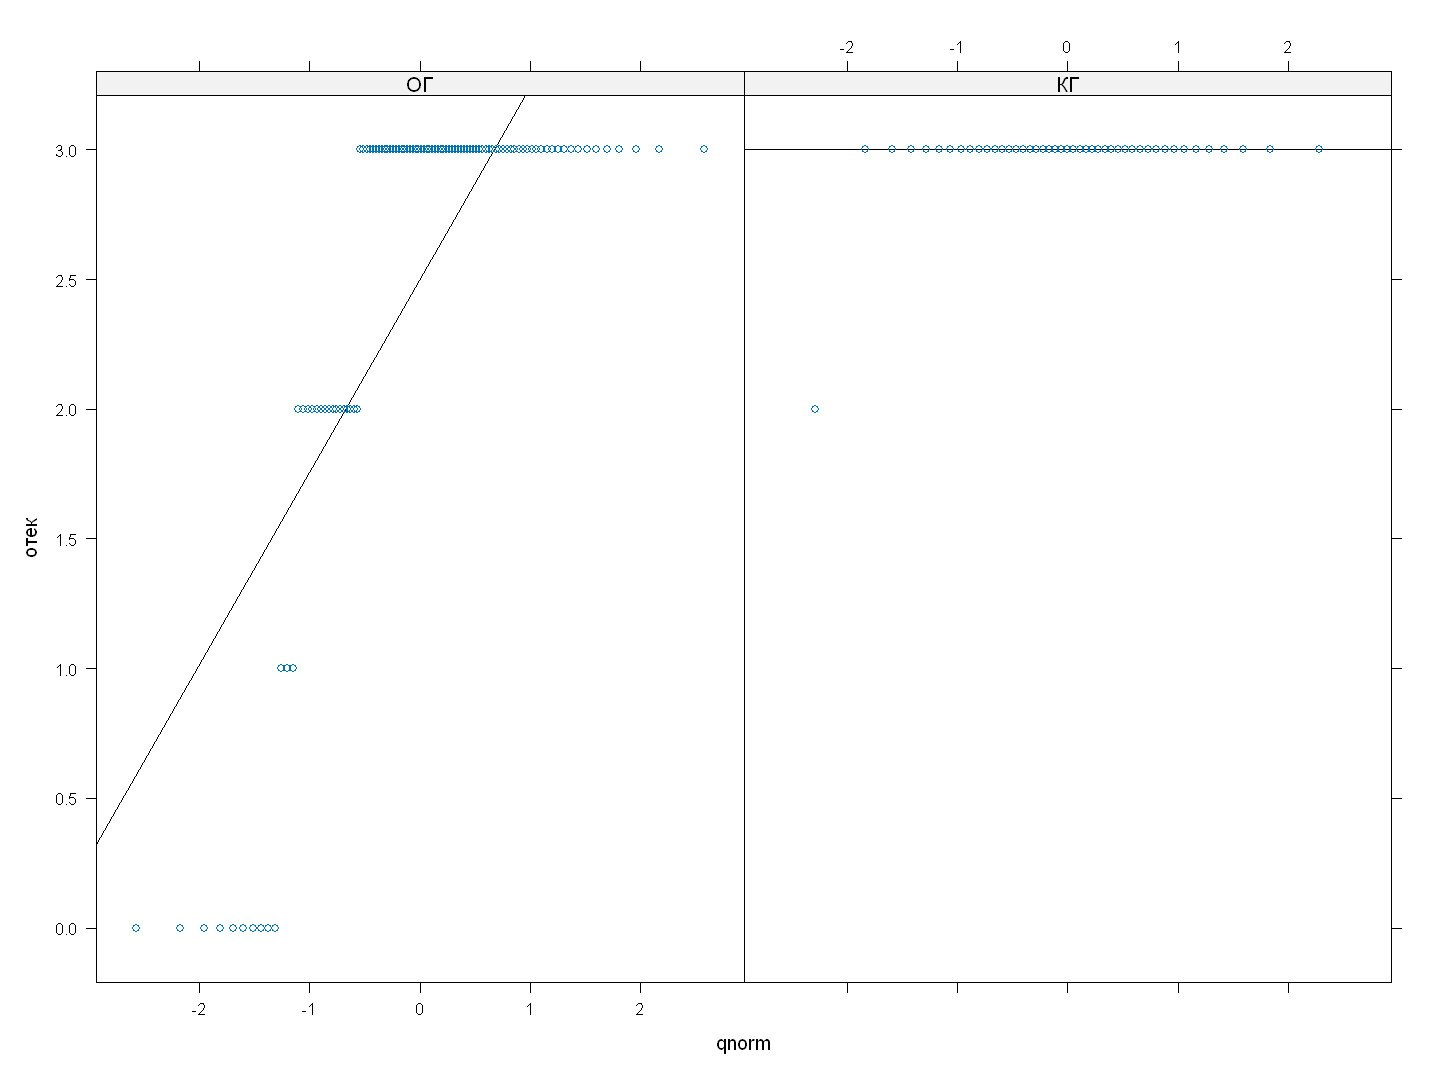

In [24]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

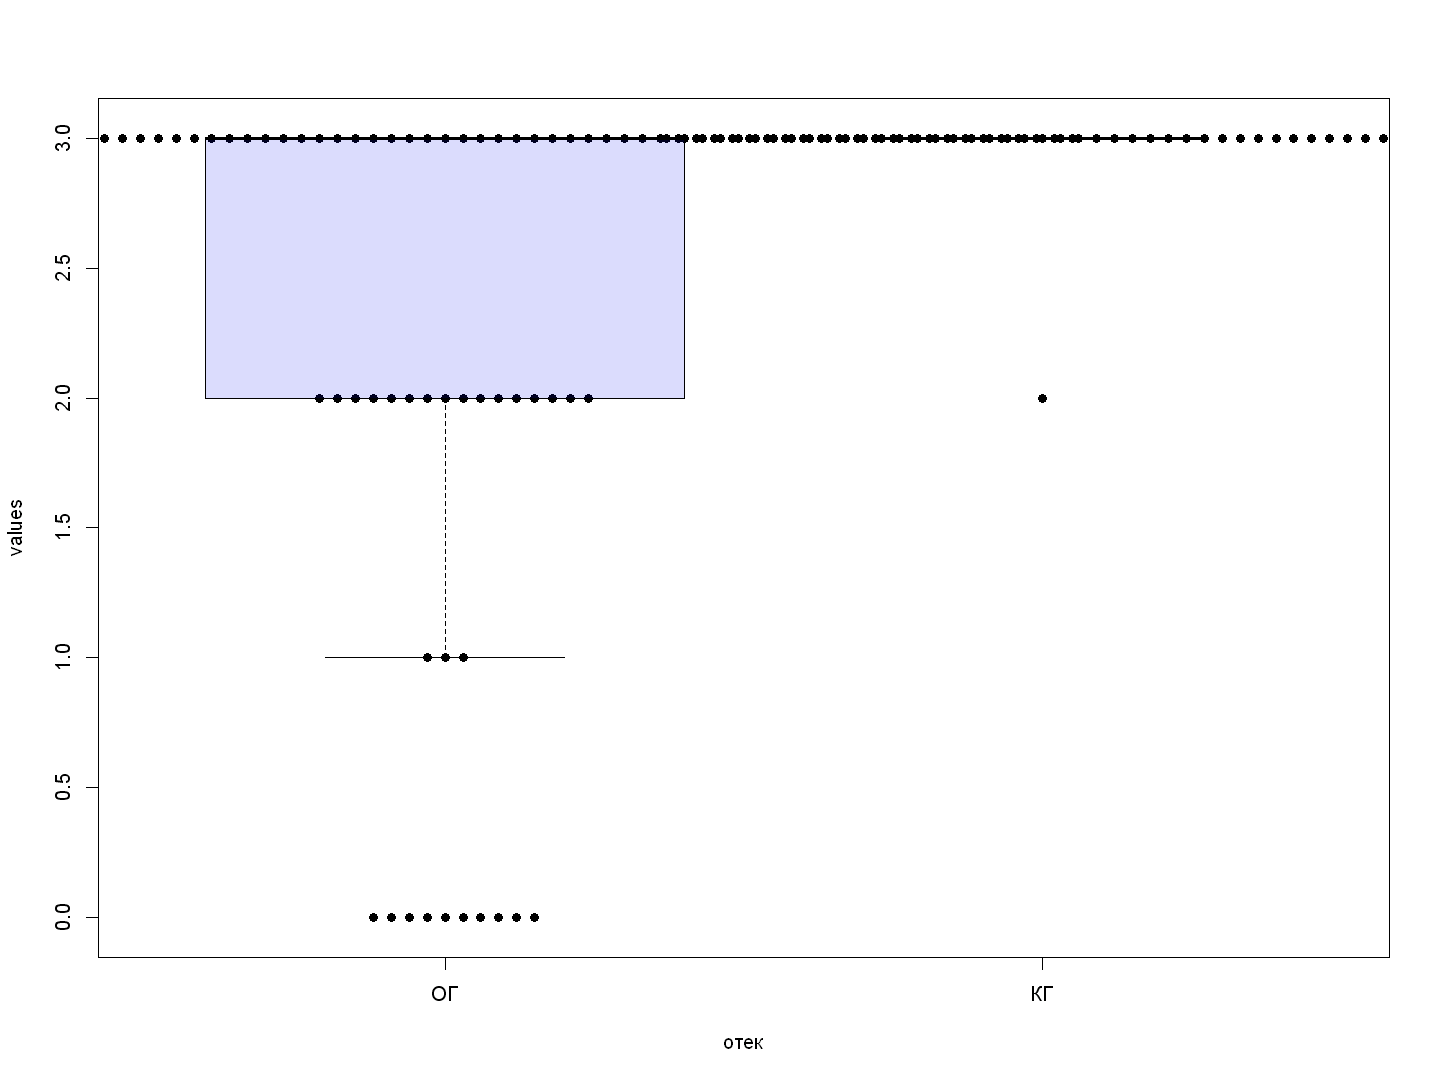

In [25]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [26]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1641, p-value = 0.0002326
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -3.6837, p-value = 0.0002299
alternative hypothesis: two.sided


## реснички эпителия

### Общее

In [27]:
parname = "реснички эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

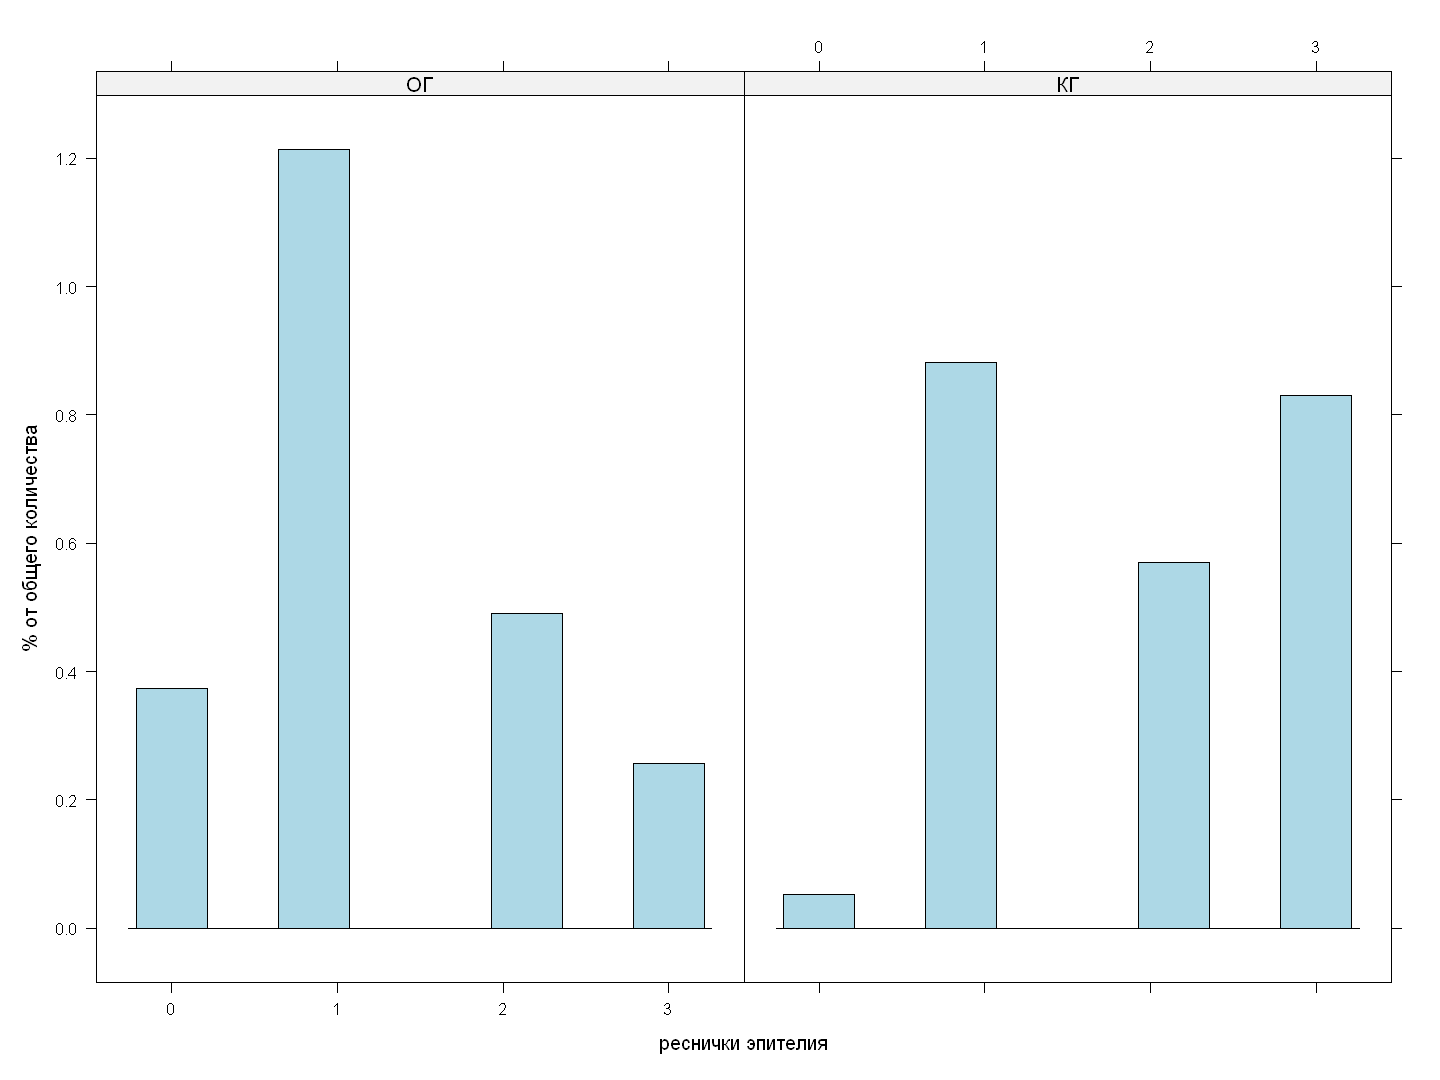

In [28]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [29]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

       mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ 1.270000 0.8628705   1  0   1   1   2    3    100
КГ 1.933333 0.9145292   2  0   1   2   3    3     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,1,1,2,3,1.270000,0.8628705,100,0
КГ,0,1,2,3,3,1.933333,0.9145292,45,0


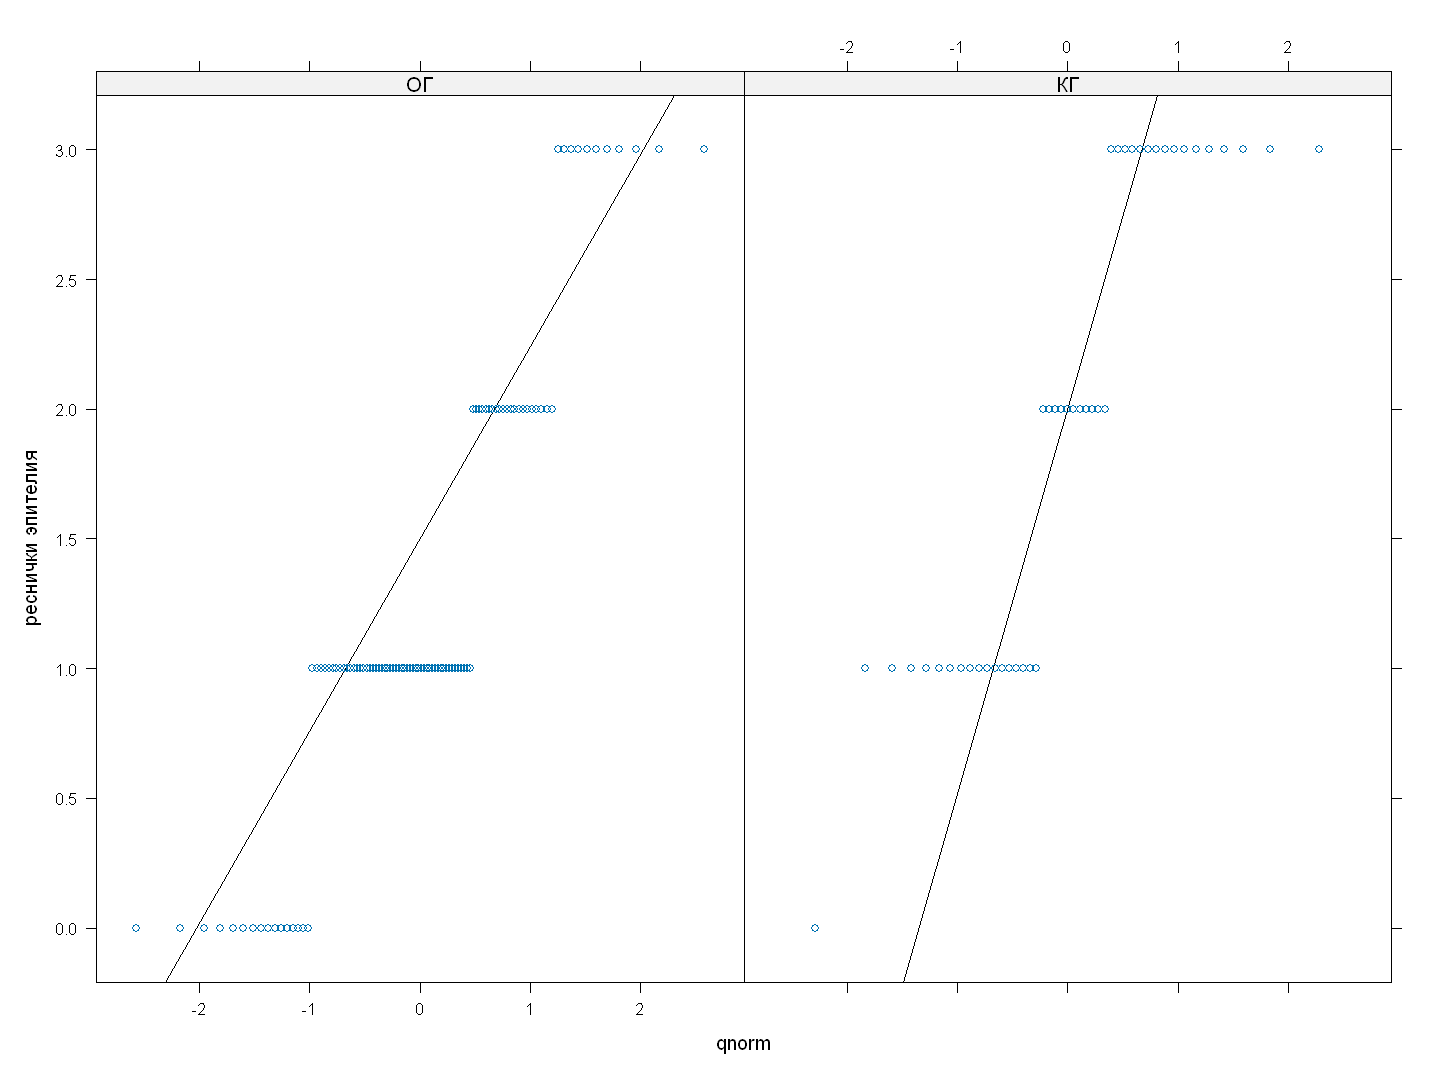

In [30]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

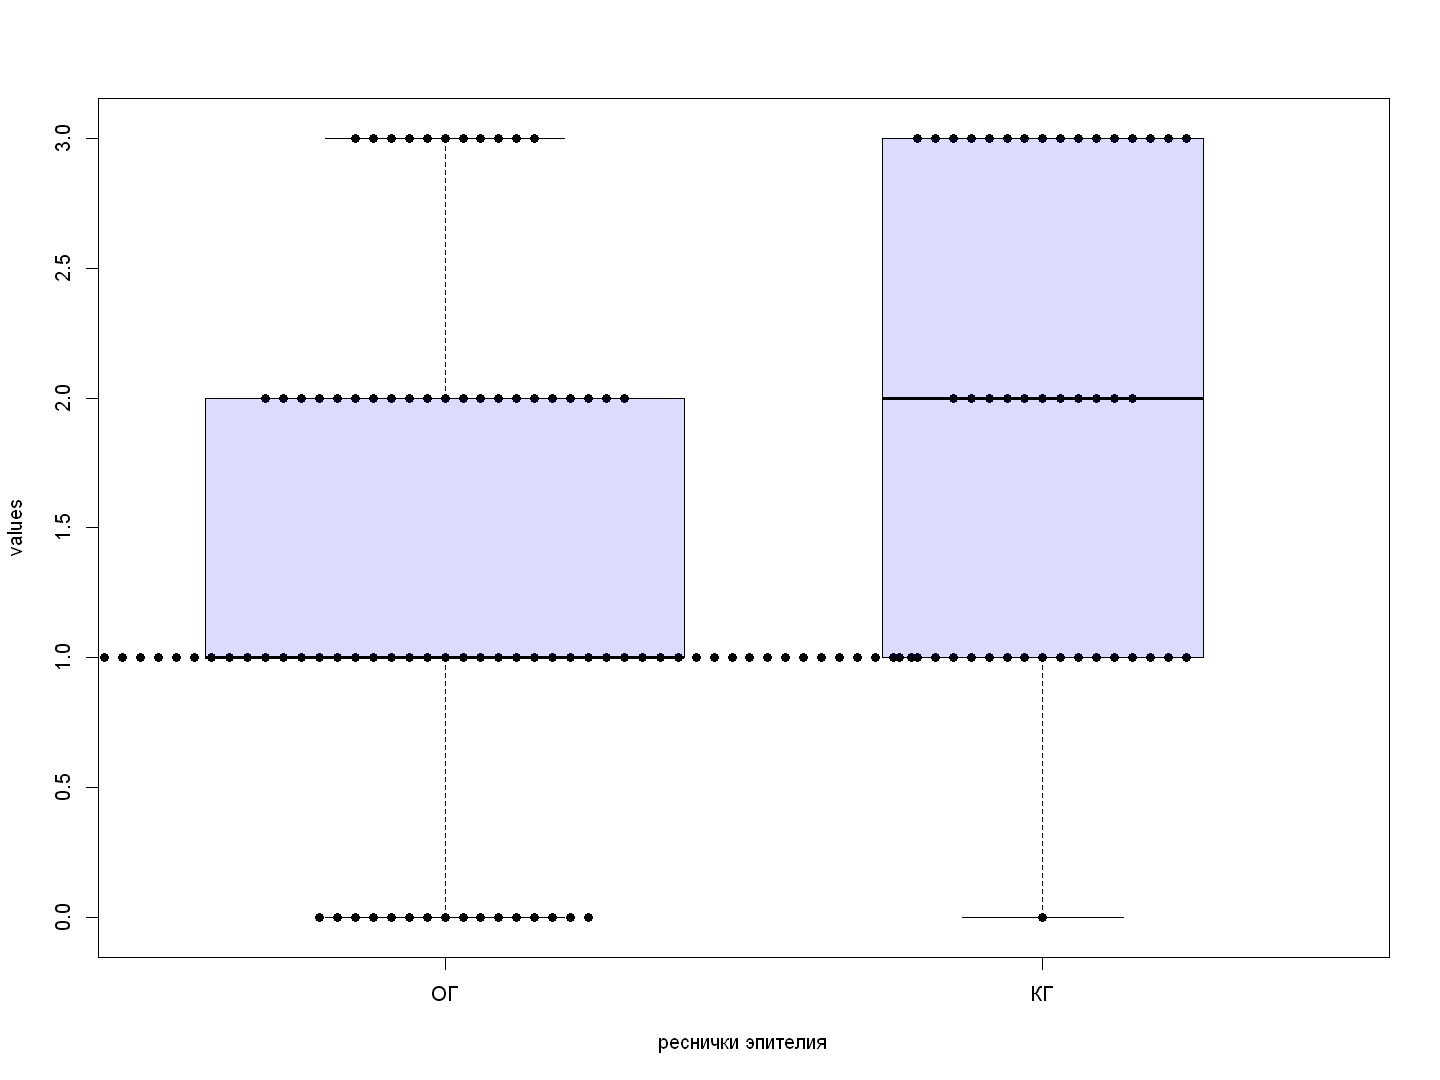

In [31]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [32]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1402.5, p-value = 0.0001074
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -3.8755, p-value = 0.0001064
alternative hypothesis: two.sided


## фиброз

### Общее

In [33]:
parname = "фиброз"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

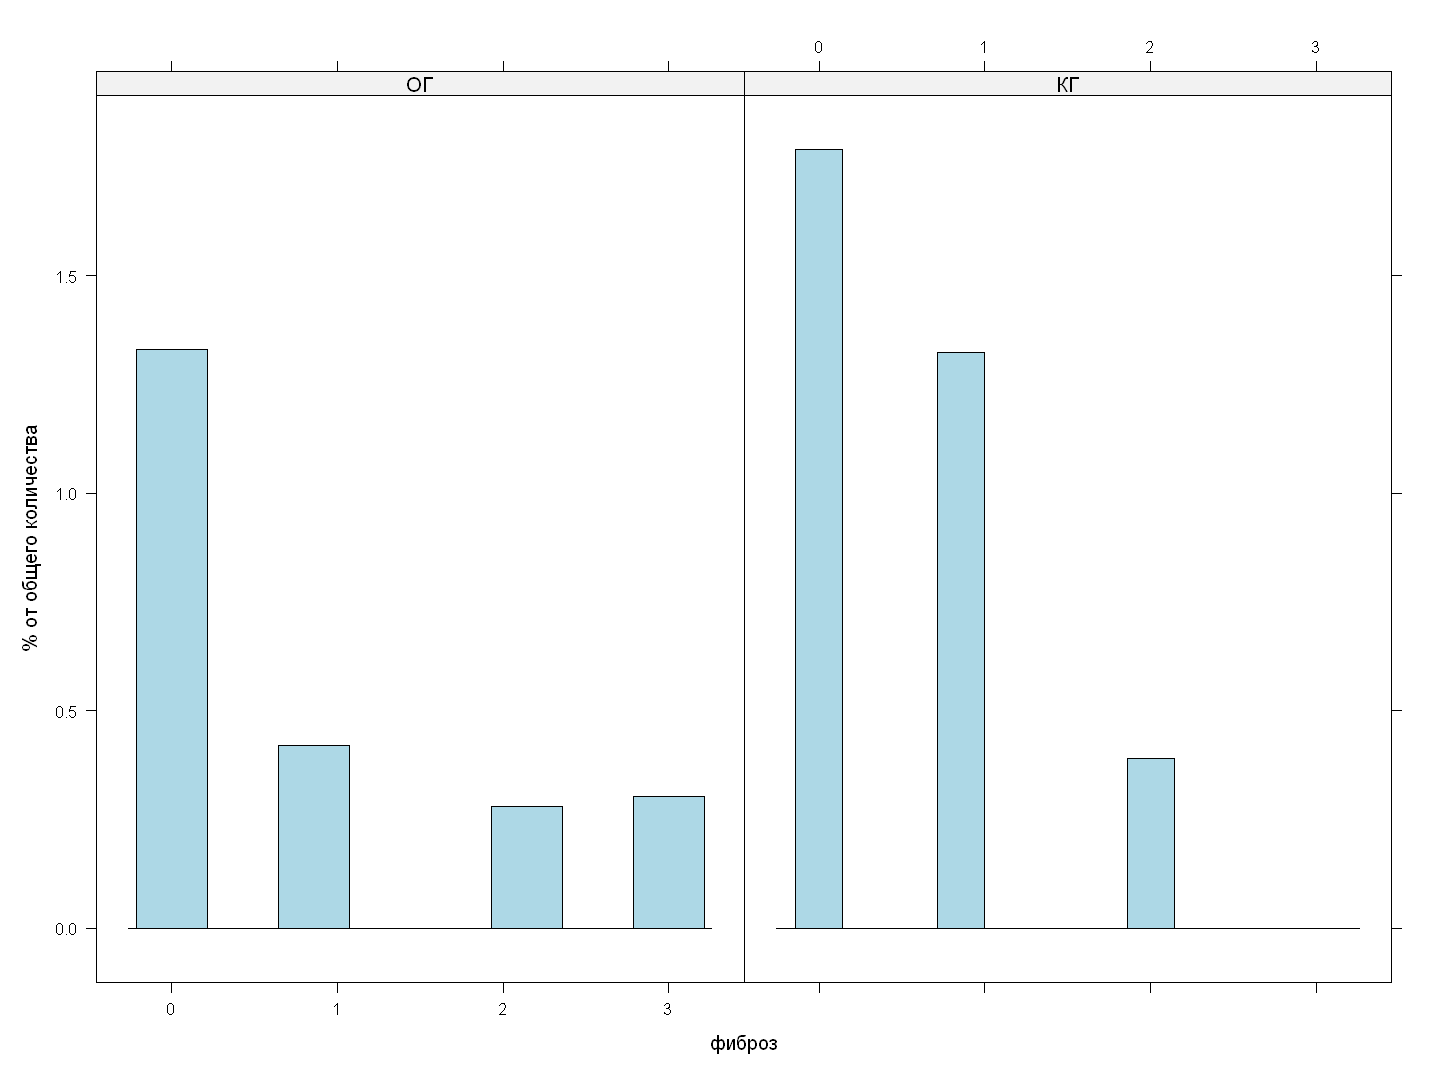

In [34]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [35]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

   mean        sd  IQR 0% 25% 50%  75% 100% data:n
ОГ 0.81 1.0889250 1.25  0   0   0 1.25    3    100
КГ 0.60 0.6875517 1.00  0   0   0 1.00    2     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,1.25,3,0.81,1.0889250,100,0
КГ,0,0,0,1.00,2,0.60,0.6875517,45,0


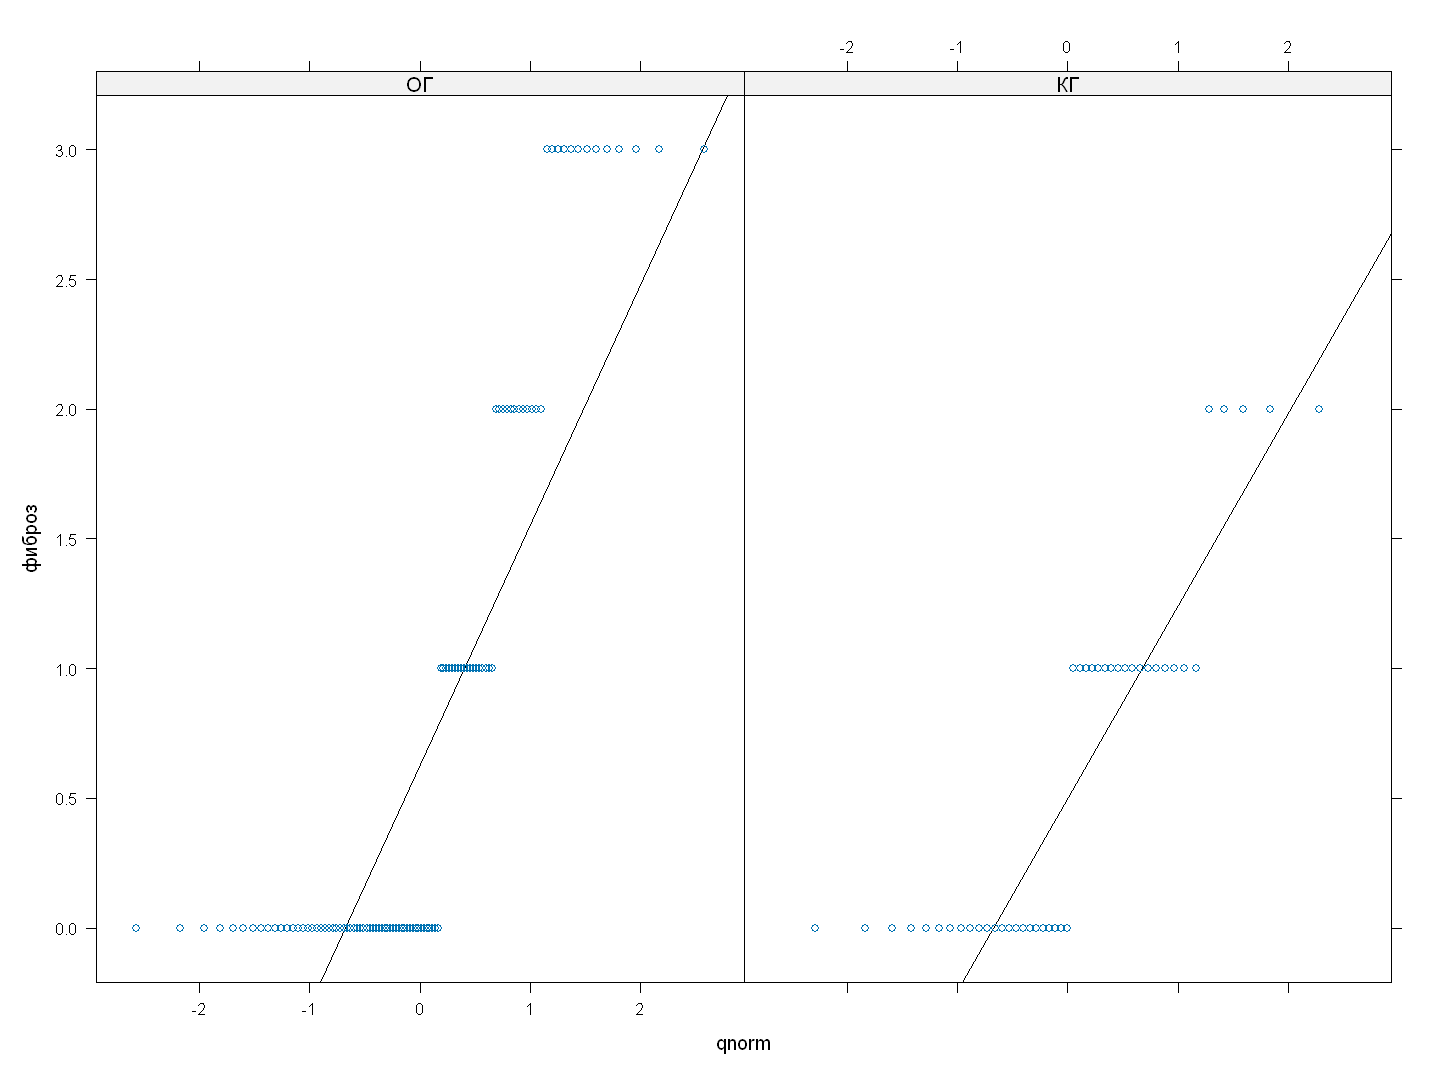

In [36]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

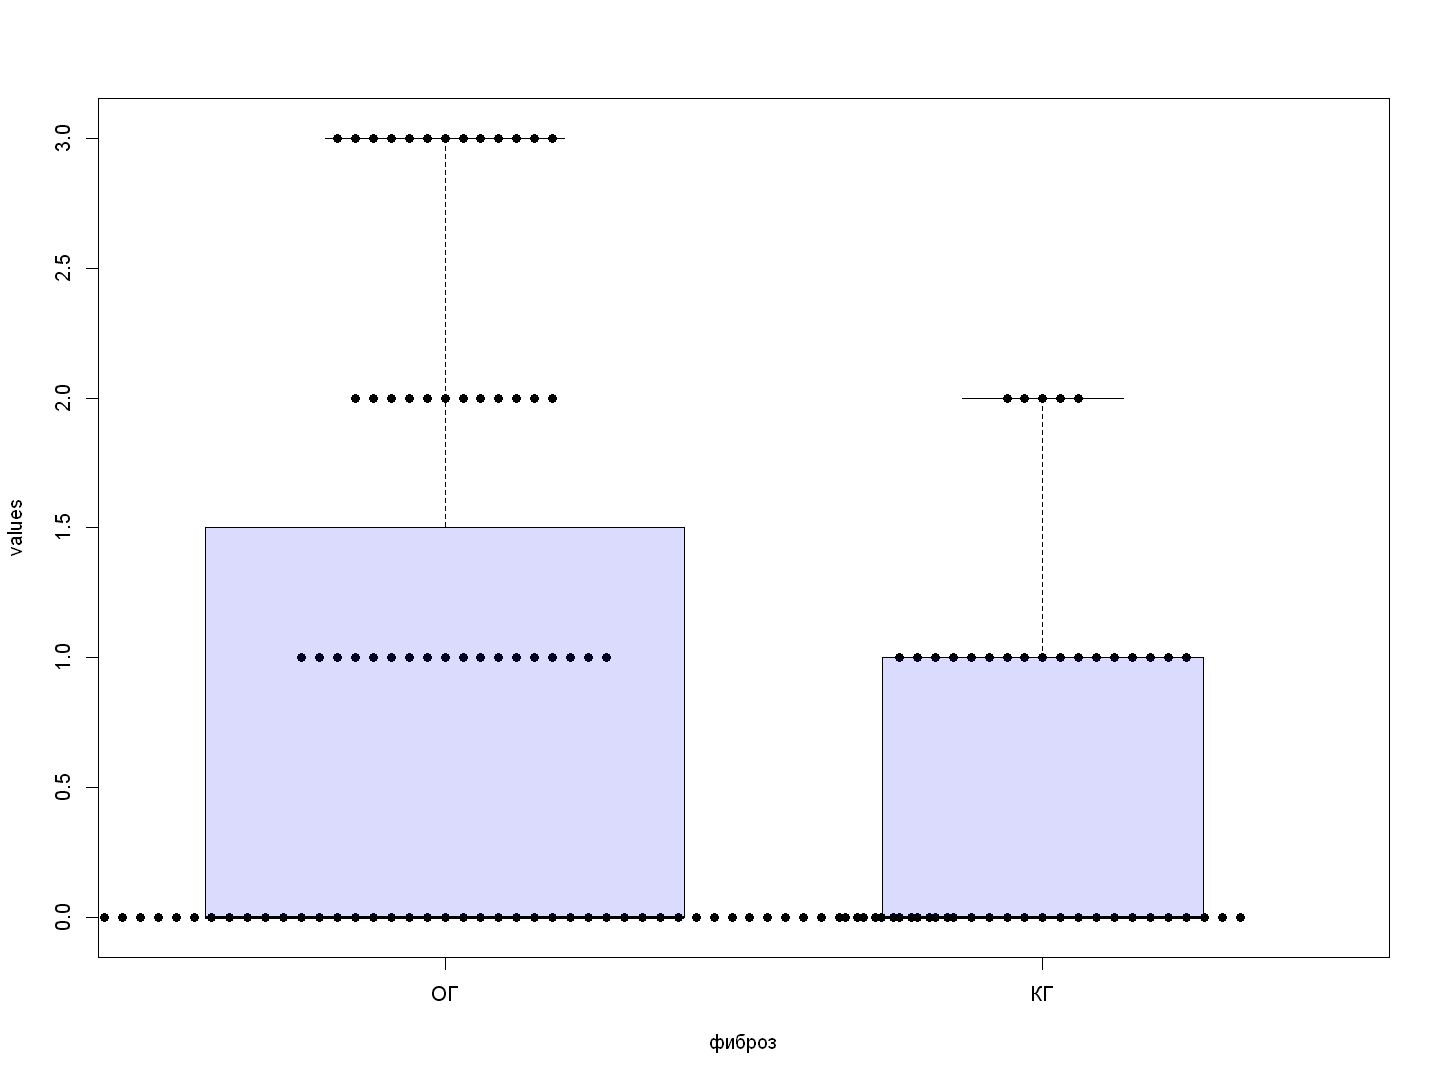

In [37]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [38]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 2317.5, p-value = 0.7512
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.31941, p-value = 0.7494
alternative hypothesis: two.sided


## гиперплазия респираторного эпителия

### Общее

In [39]:
parname = "гиперплазия респираторного эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

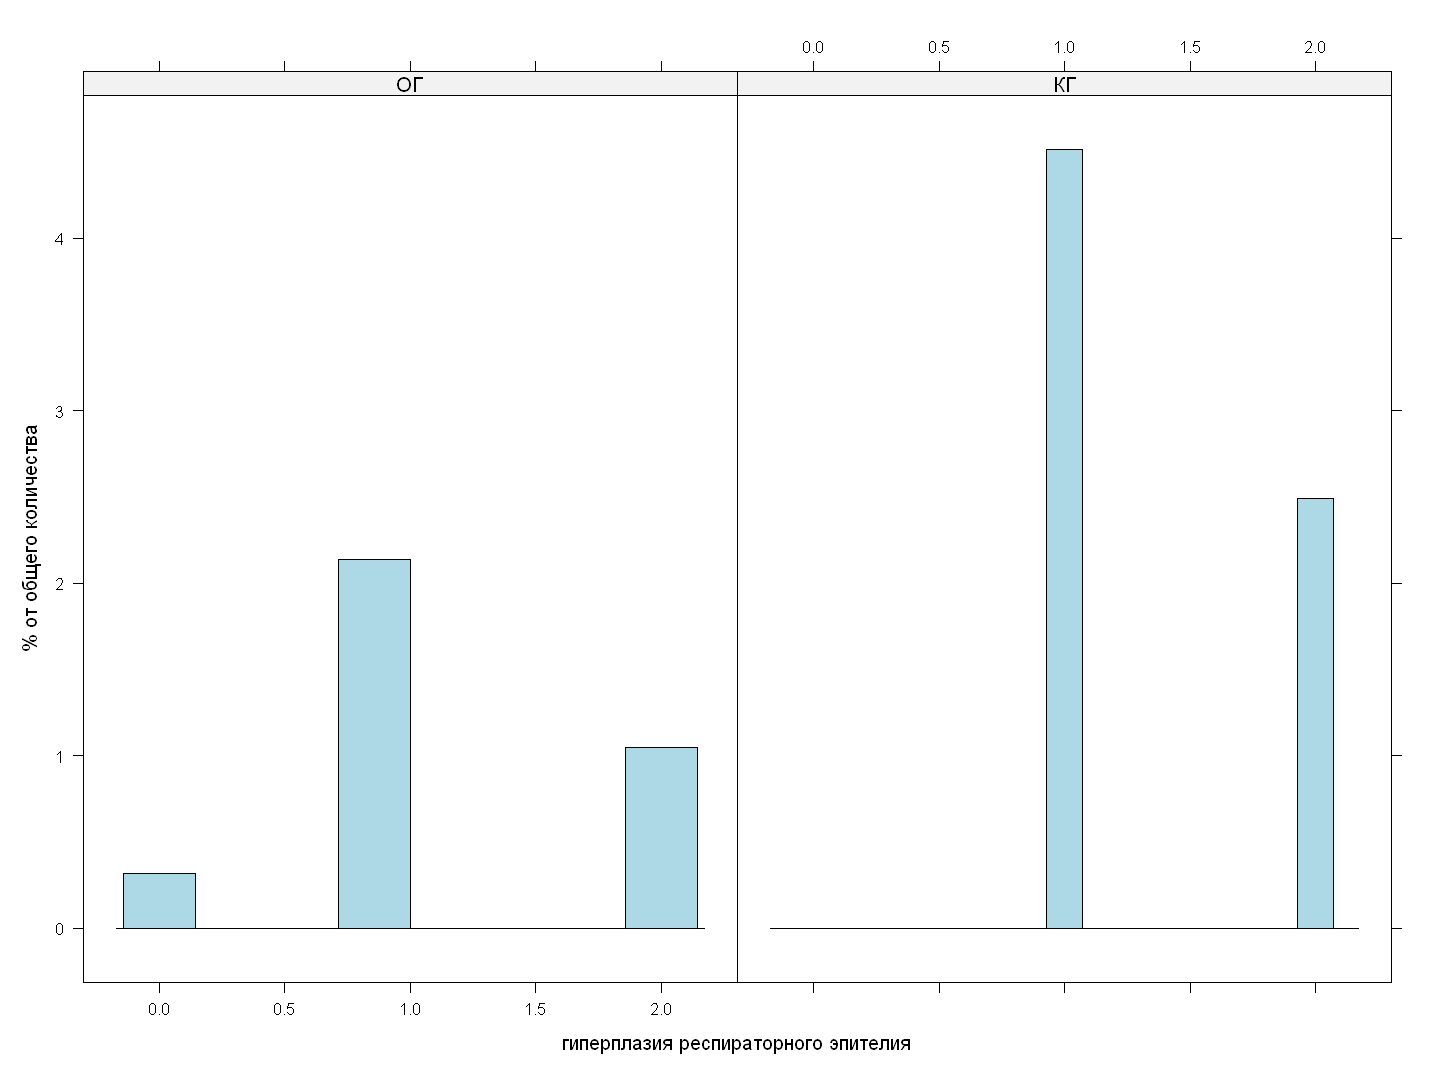

In [40]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [41]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

       mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ 1.210000 0.5910955   1  0   1   1   2    2    100
КГ 1.355556 0.4840903   1  1   1   1   2    2     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,1,1,2,2,1.210000,0.5910955,100,0
КГ,1,1,1,2,2,1.355556,0.4840903,45,0


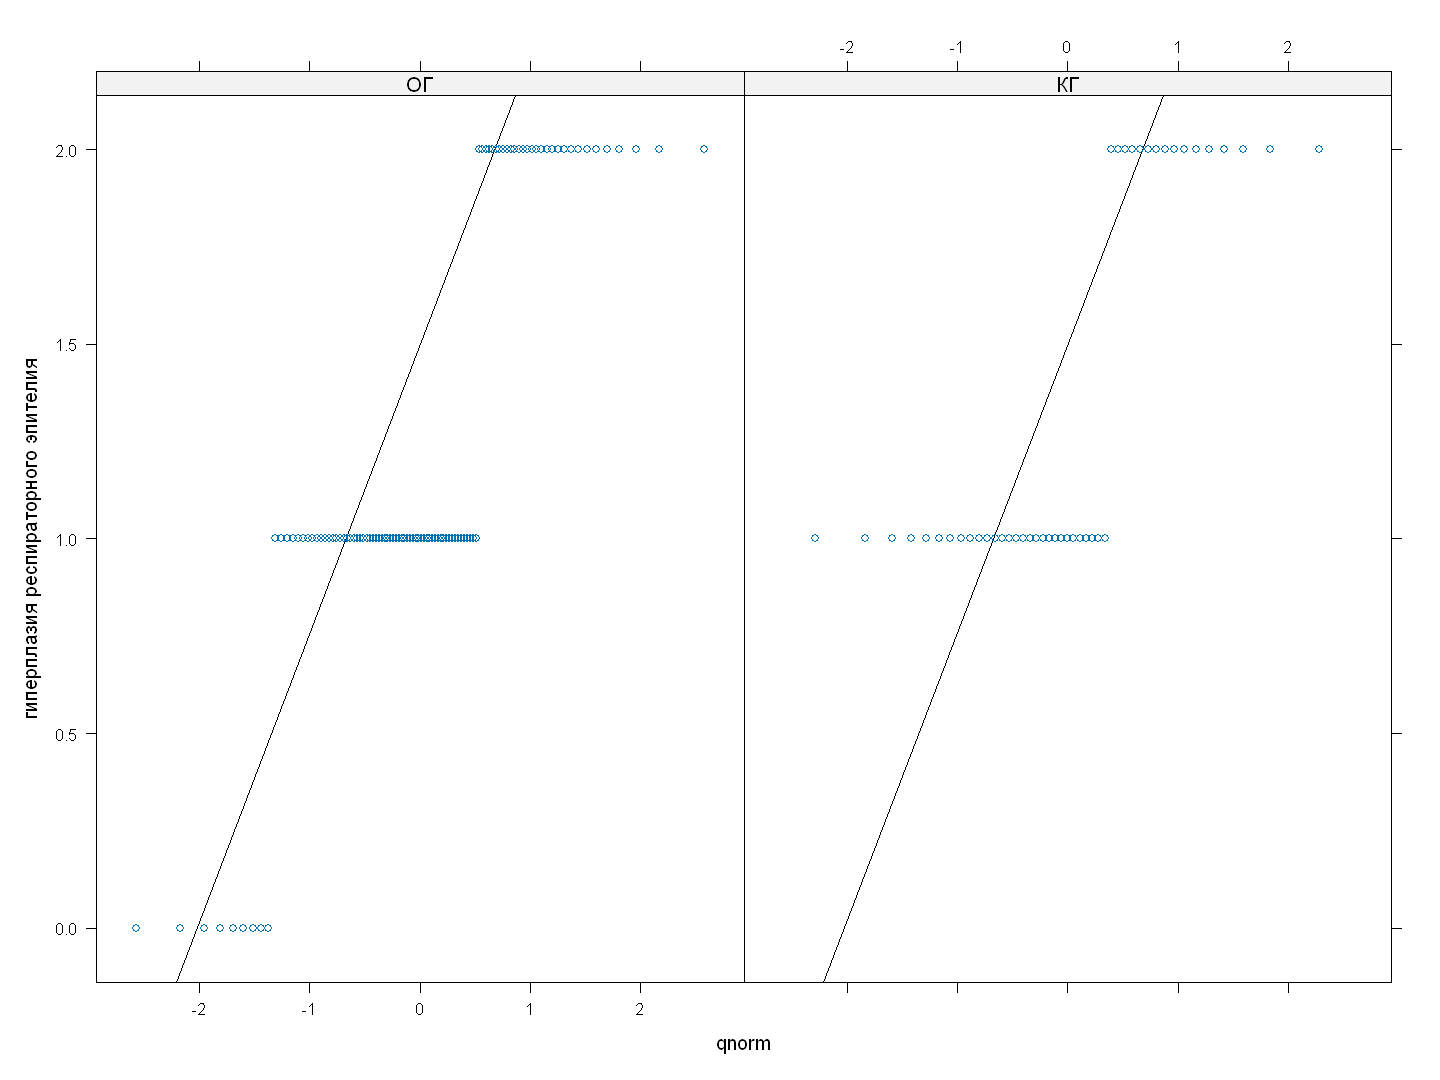

In [42]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

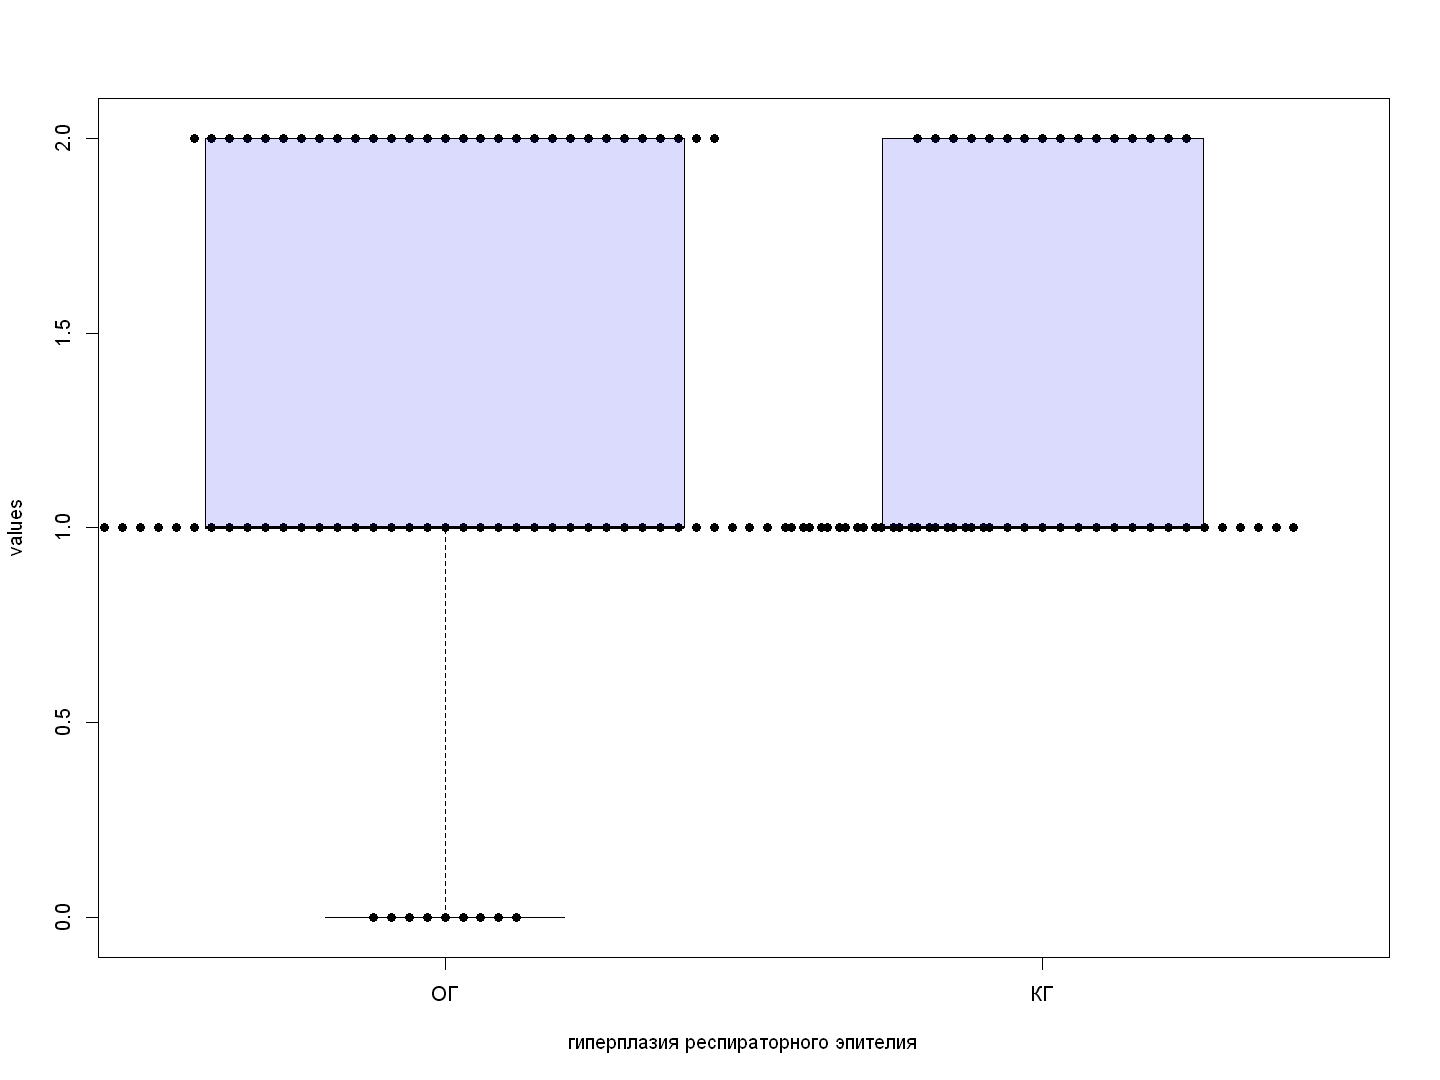

In [43]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [44]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1994.5, p-value = 0.2017
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -1.2791, p-value = 0.2009
alternative hypothesis: two.sided


## плоскоклеточная метаплазия

### Общее

In [45]:
parname = "плоскоклеточная метаплазия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

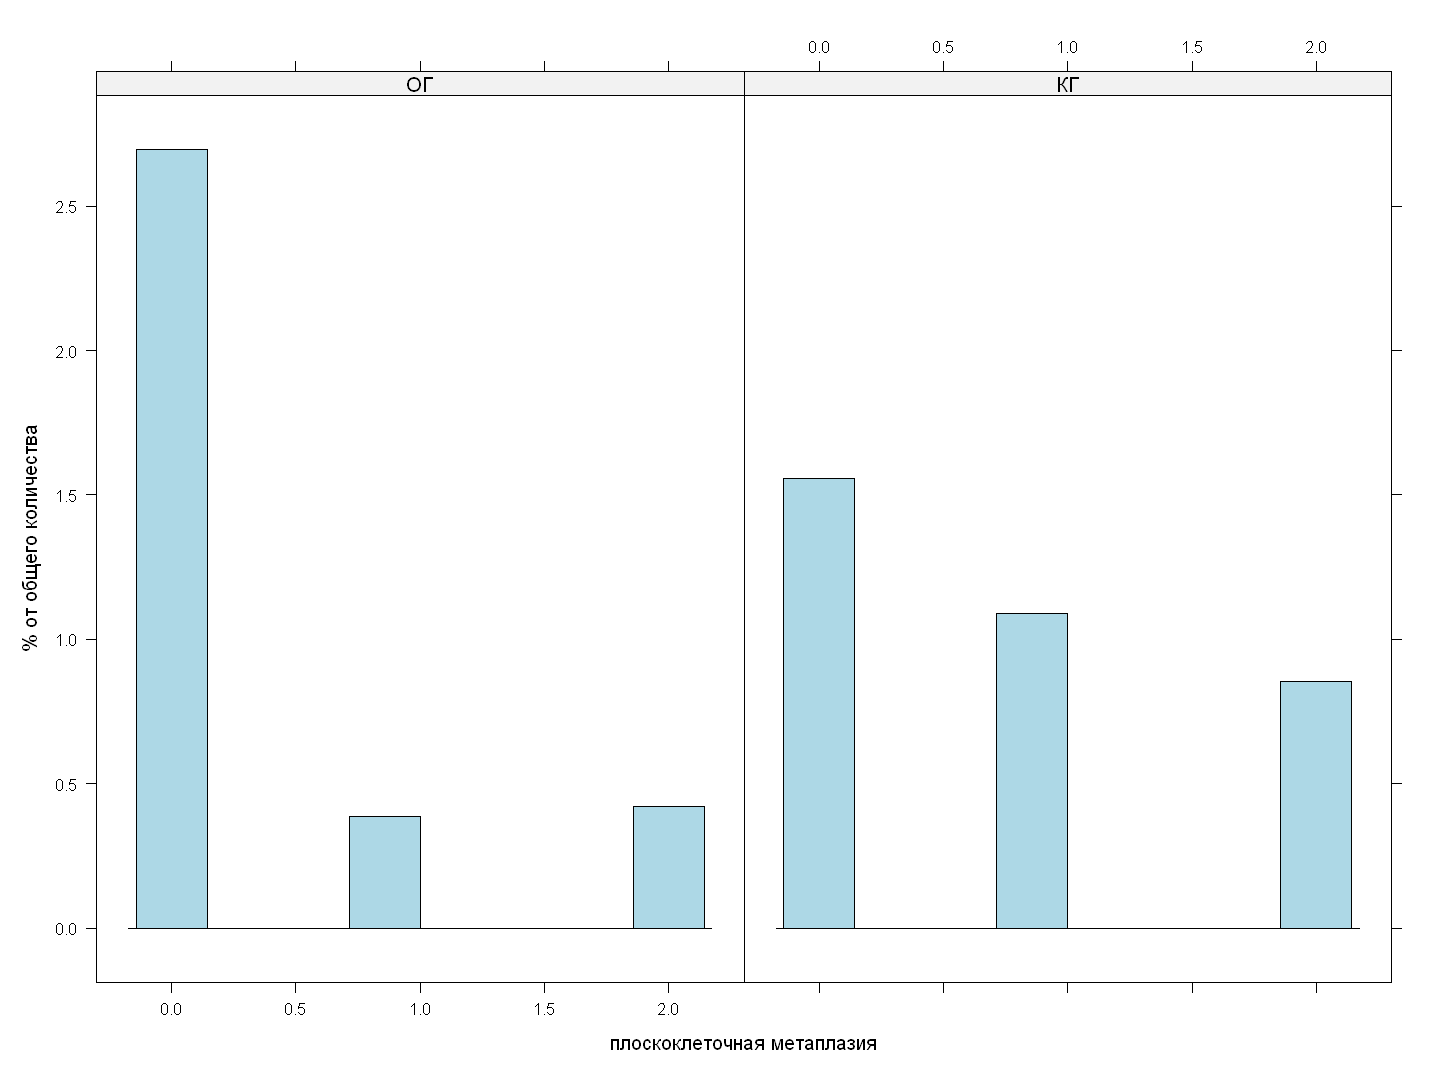

In [46]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [47]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

   mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ 0.35 0.6871843   0  0   0   0   0    2    100
КГ 0.80 0.8146388   1  0   0   1   1    2     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0,2,0.35,0.6871843,100,0
КГ,0,0,1,1,2,0.80,0.8146388,45,0


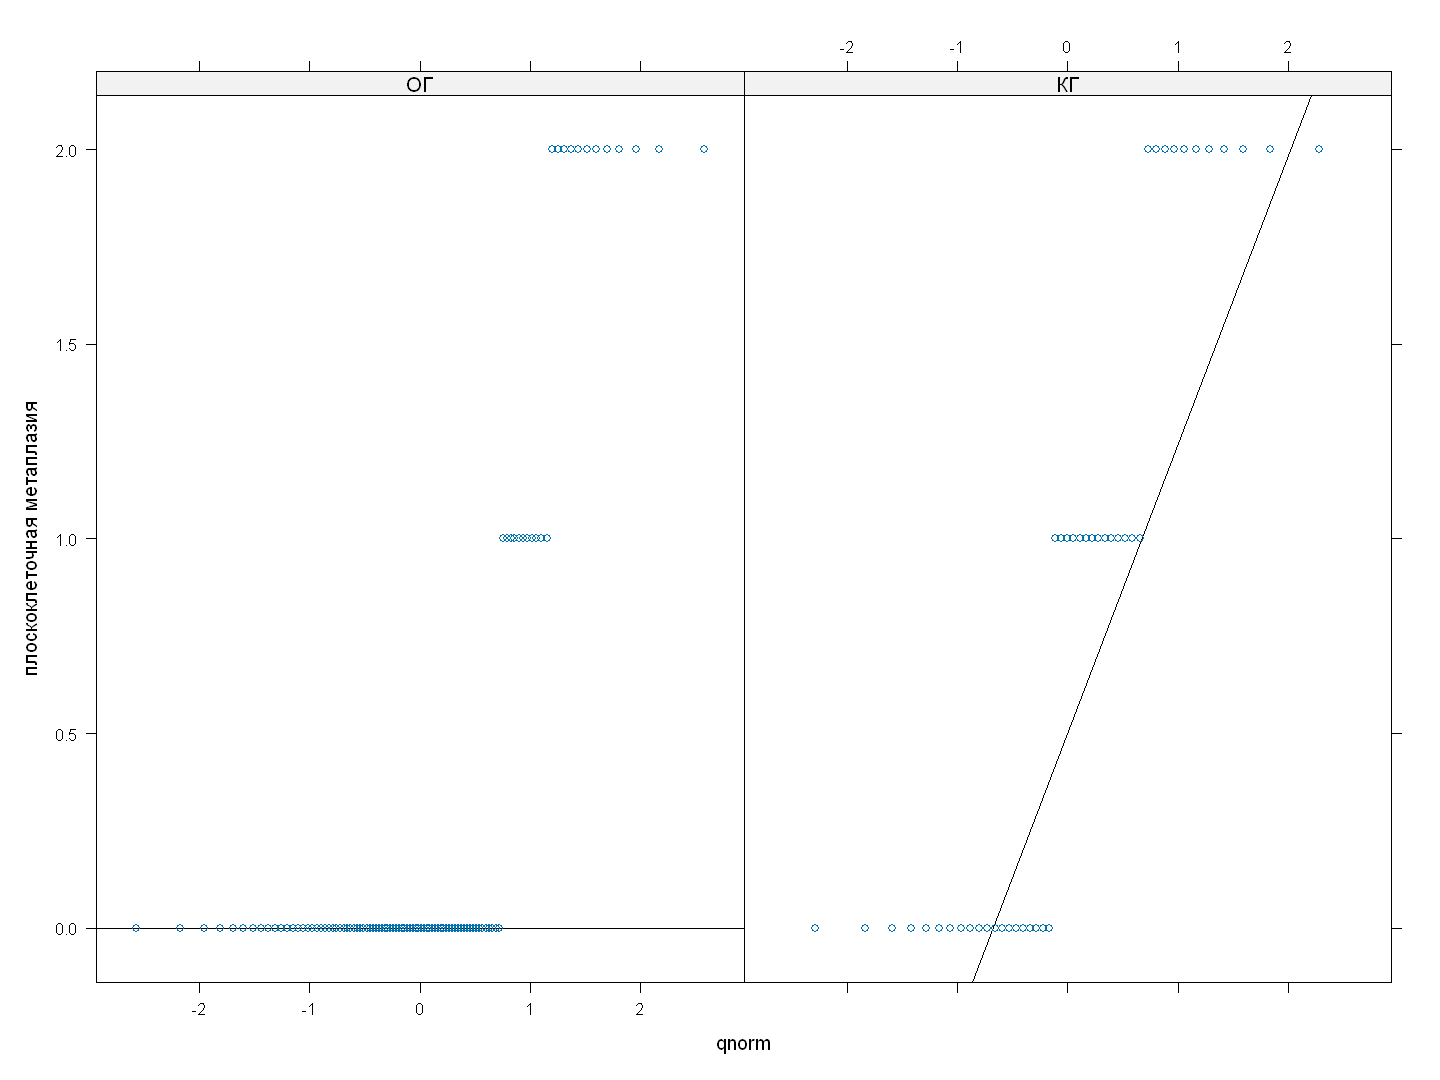

In [48]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

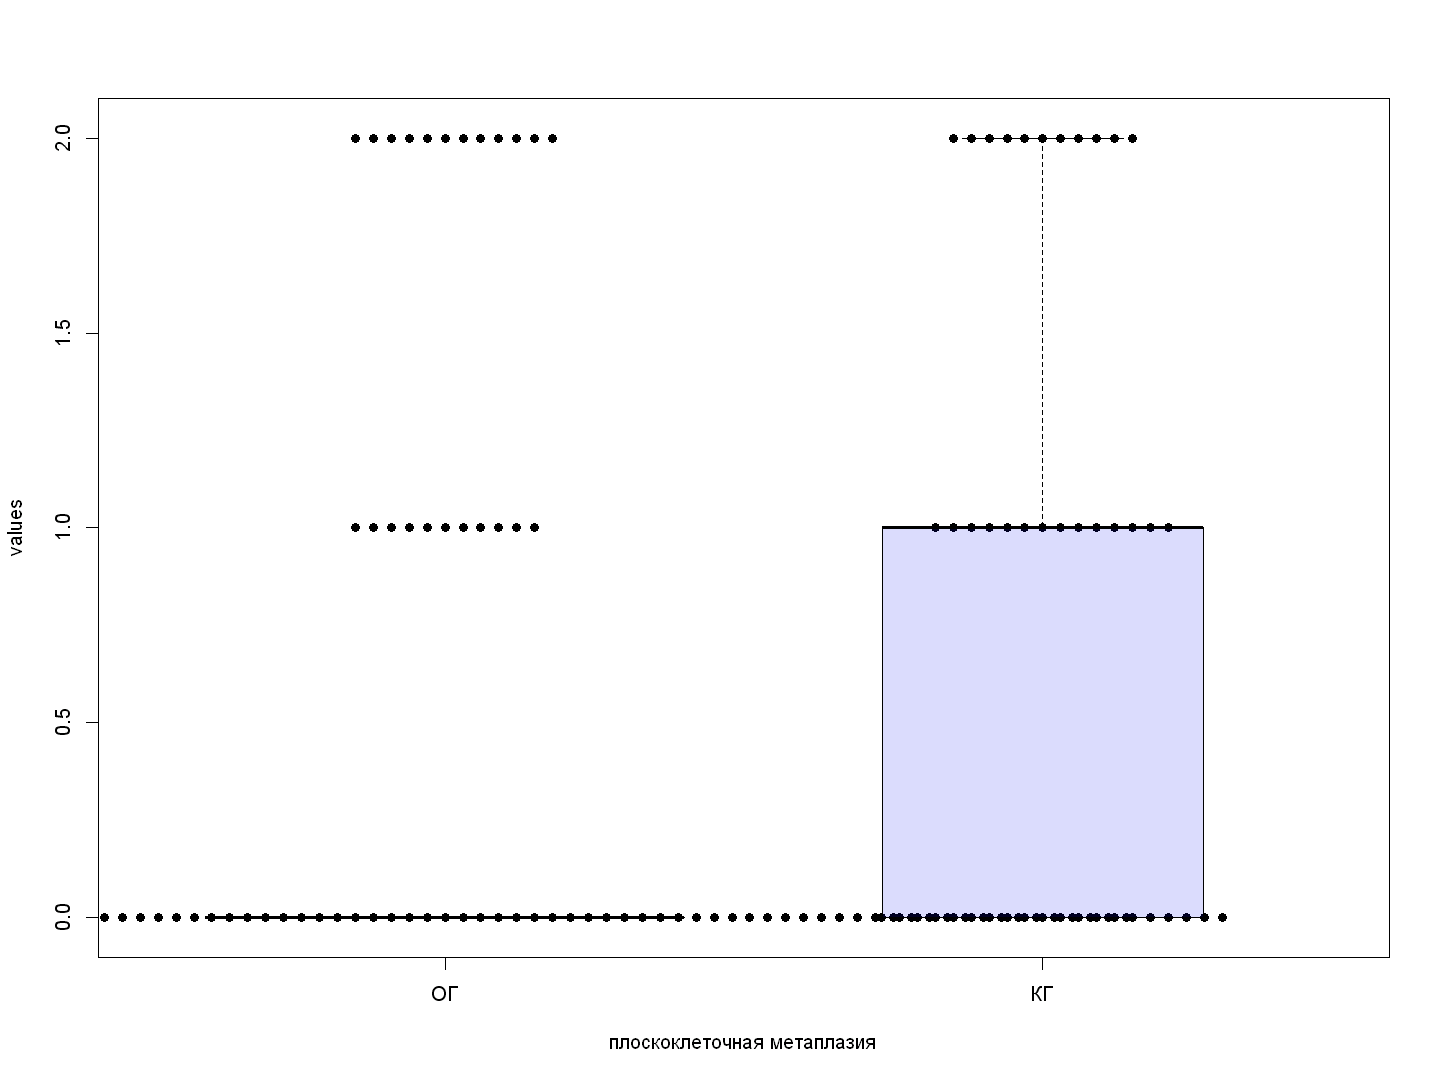

In [49]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [50]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1541, p-value = 0.0002714
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = -3.6437, p-value = 0.0002687
alternative hypothesis: two.sided


## эозинофилы

### Общее

In [51]:
parname = "эозинофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

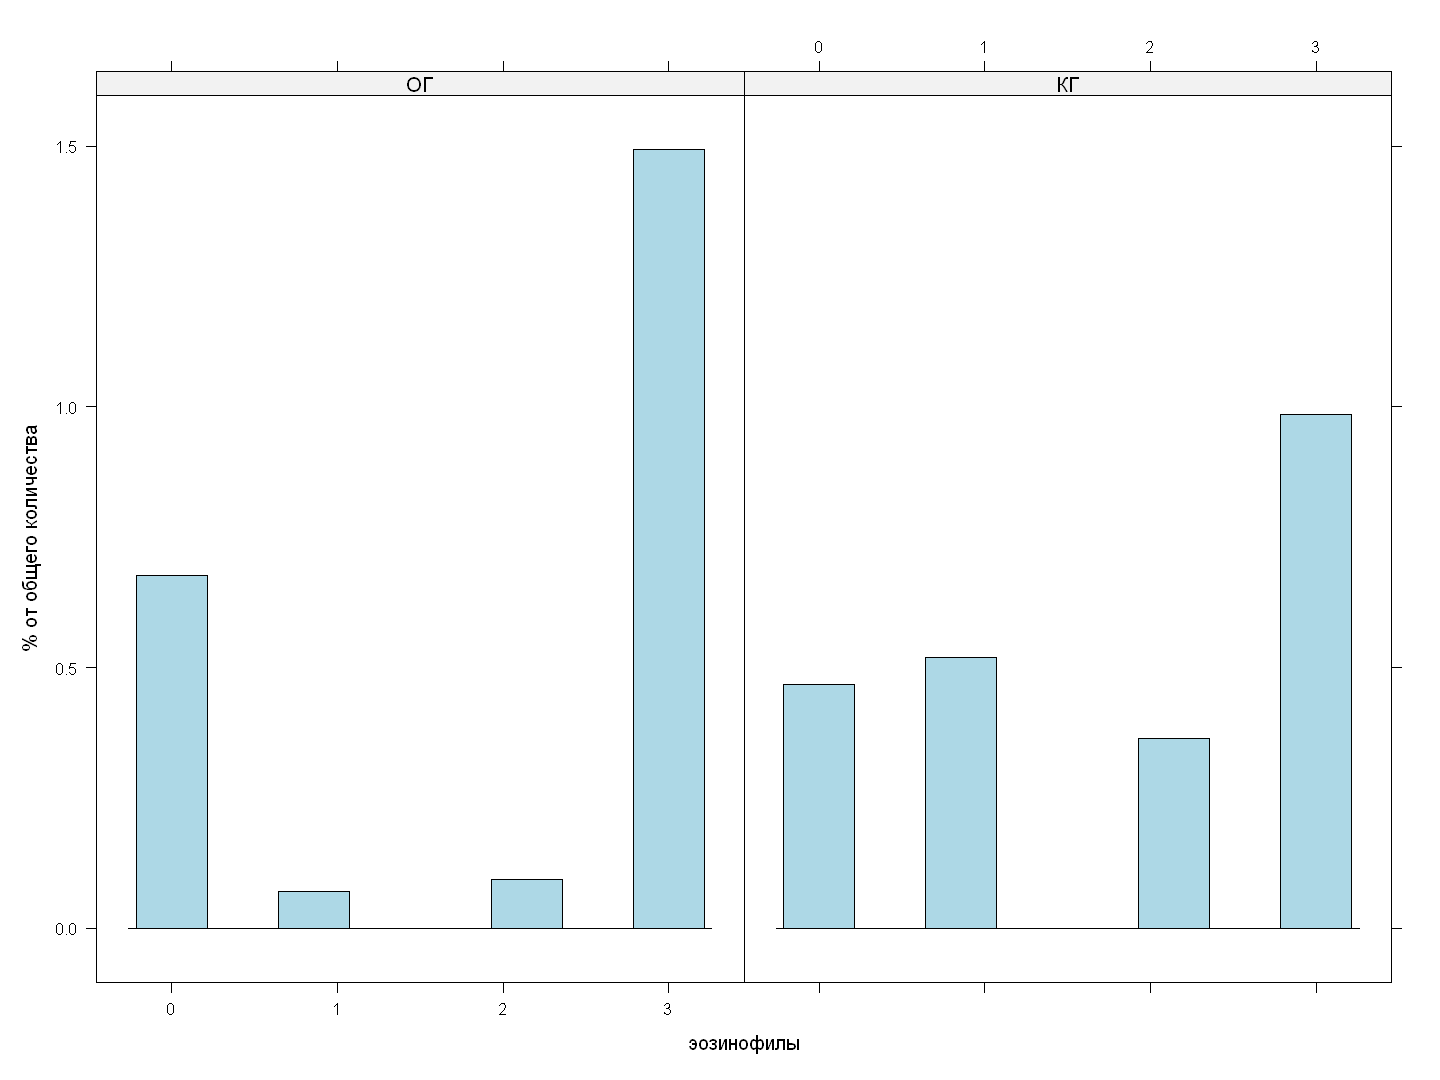

In [52]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [53]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

   mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ 2.03 1.359256   3  0   0   3   3    3    100
КГ 1.80 1.198484   2  0   1   2   3    3     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,3,3,3,2.03,1.359256,100,0
КГ,0,1,2,3,3,1.80,1.198484,45,0


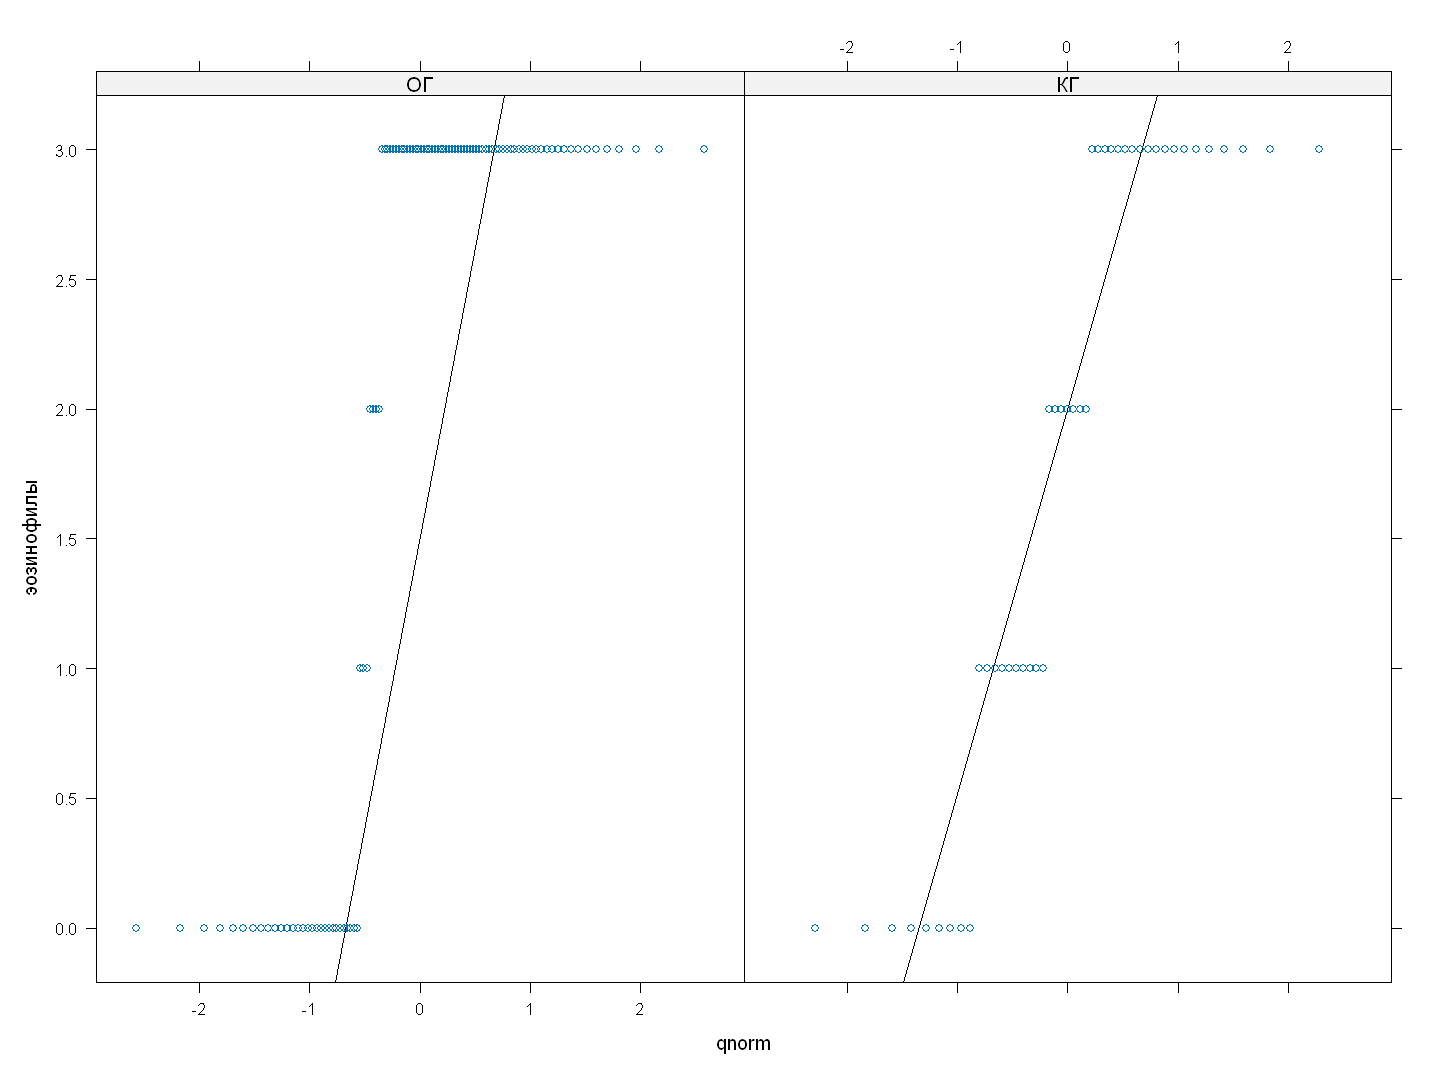

In [54]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

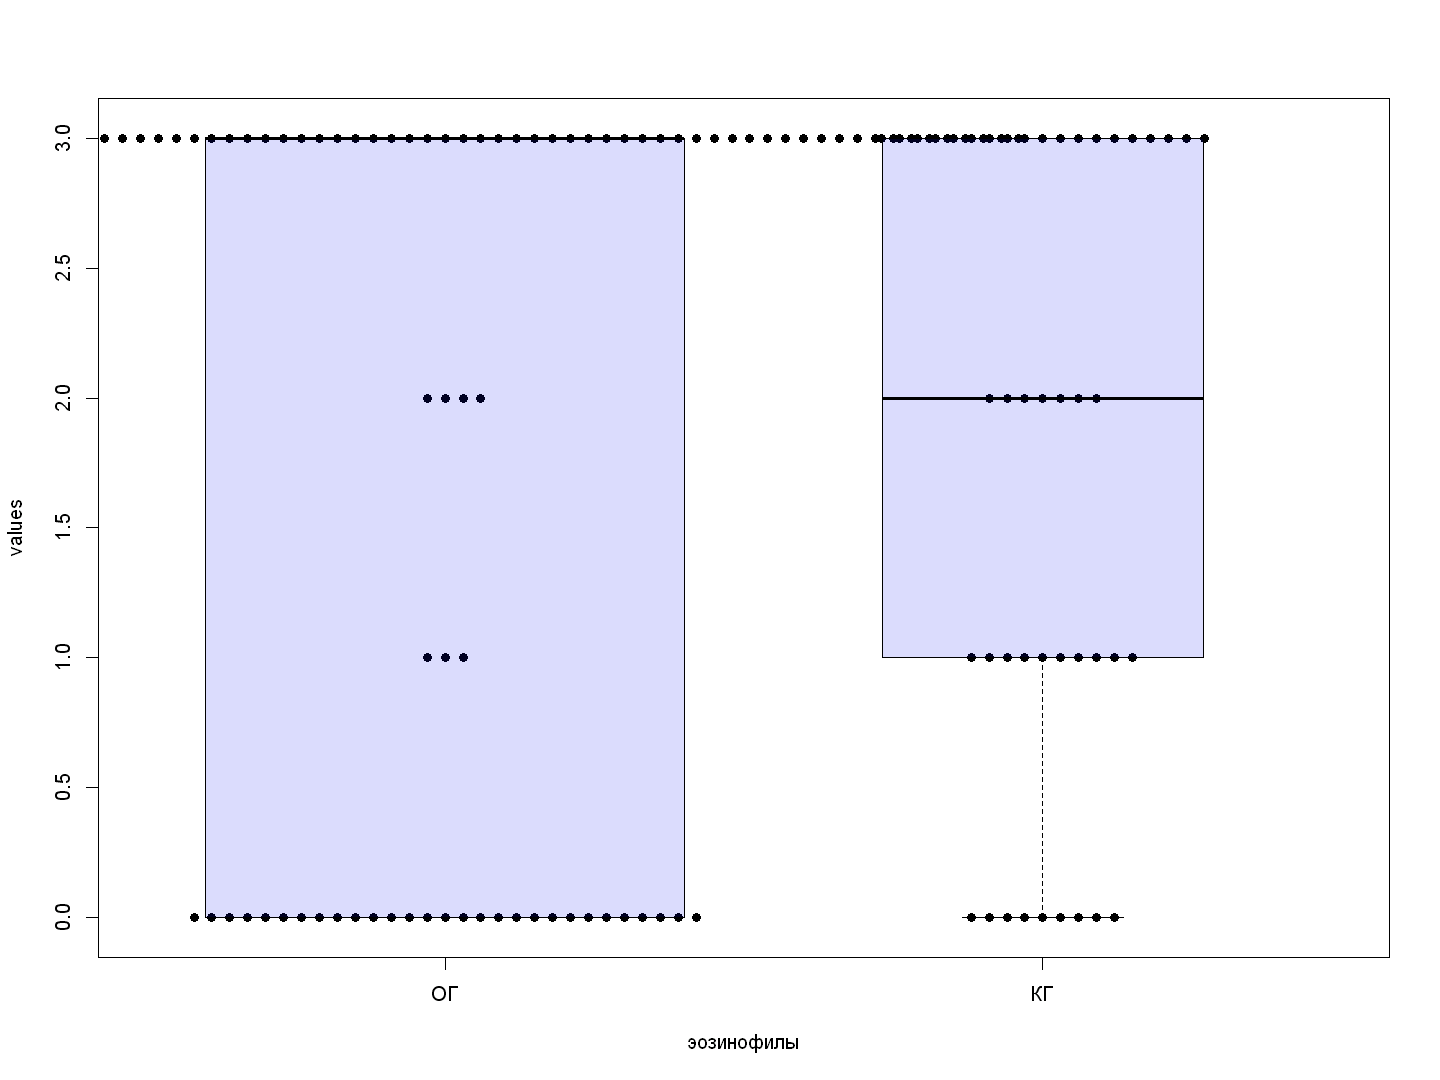

In [55]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [56]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
            )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 2534.5, p-value = 0.173
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 1.3651, p-value = 0.1722
alternative hypothesis: two.sided


## нейтрофилы

### Общее

In [57]:
parname = "нейтрофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

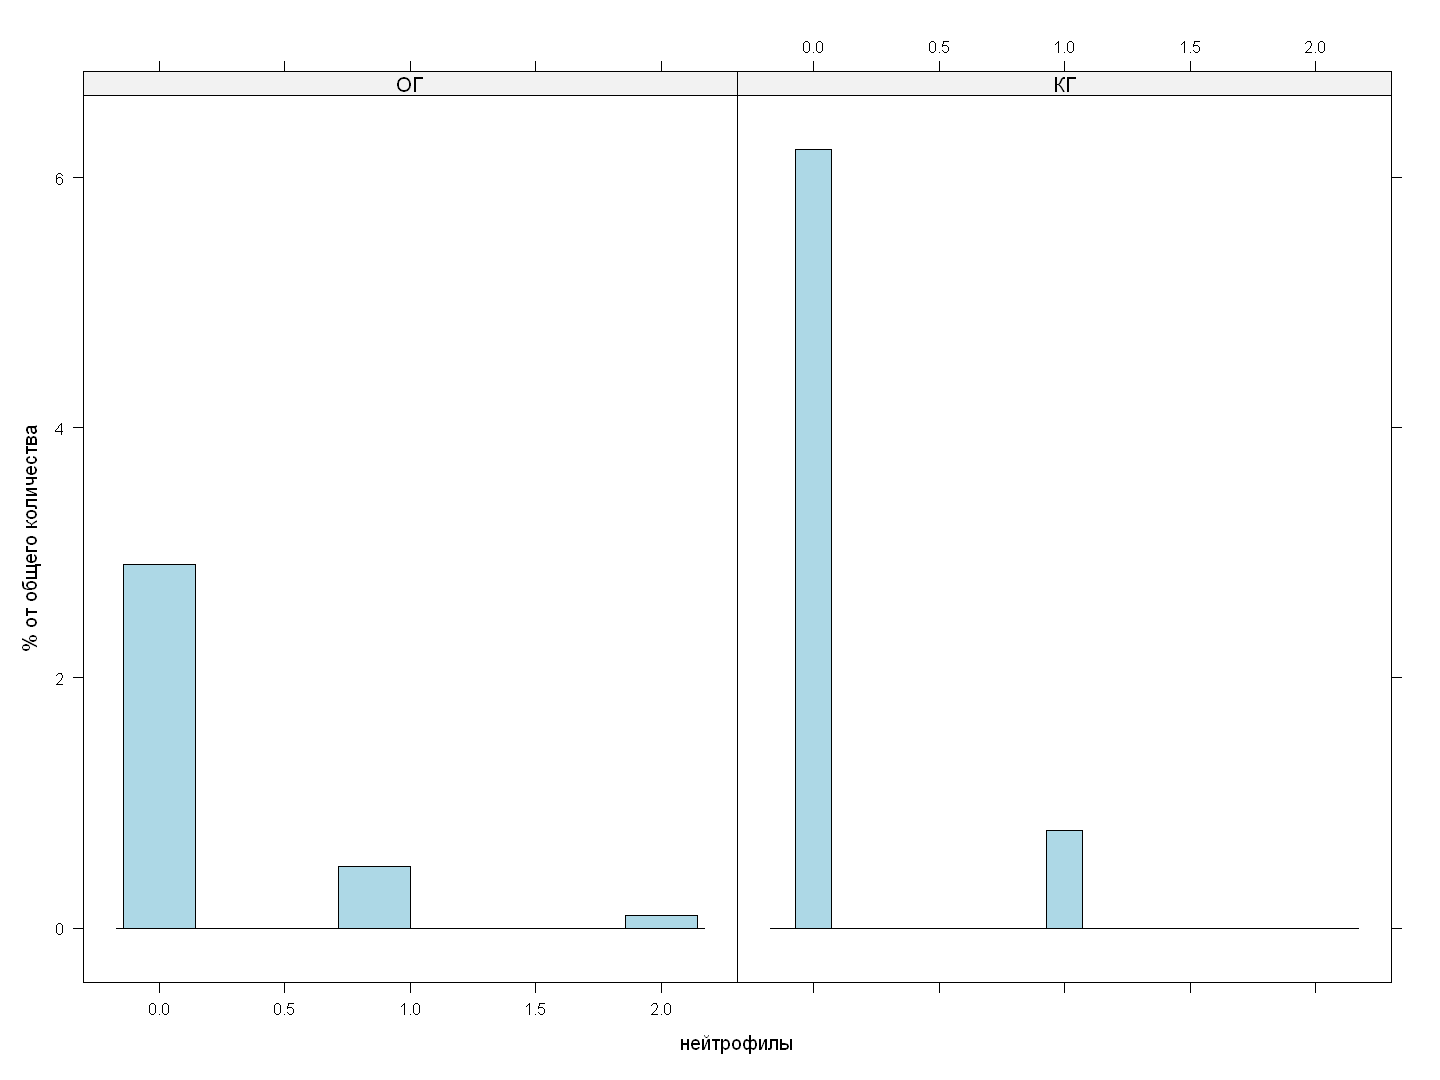

In [58]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [59]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = parameter)
favstats(values ~ parameter)

        mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ 0.2000000 0.4714045   0  0   0   0   0    2    100
КГ 0.1111111 0.3178209   0  0   0   0   0    1     45

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0,2,0.2000000,0.4714045,100,0
КГ,0,0,0,0,1,0.1111111,0.3178209,45,0


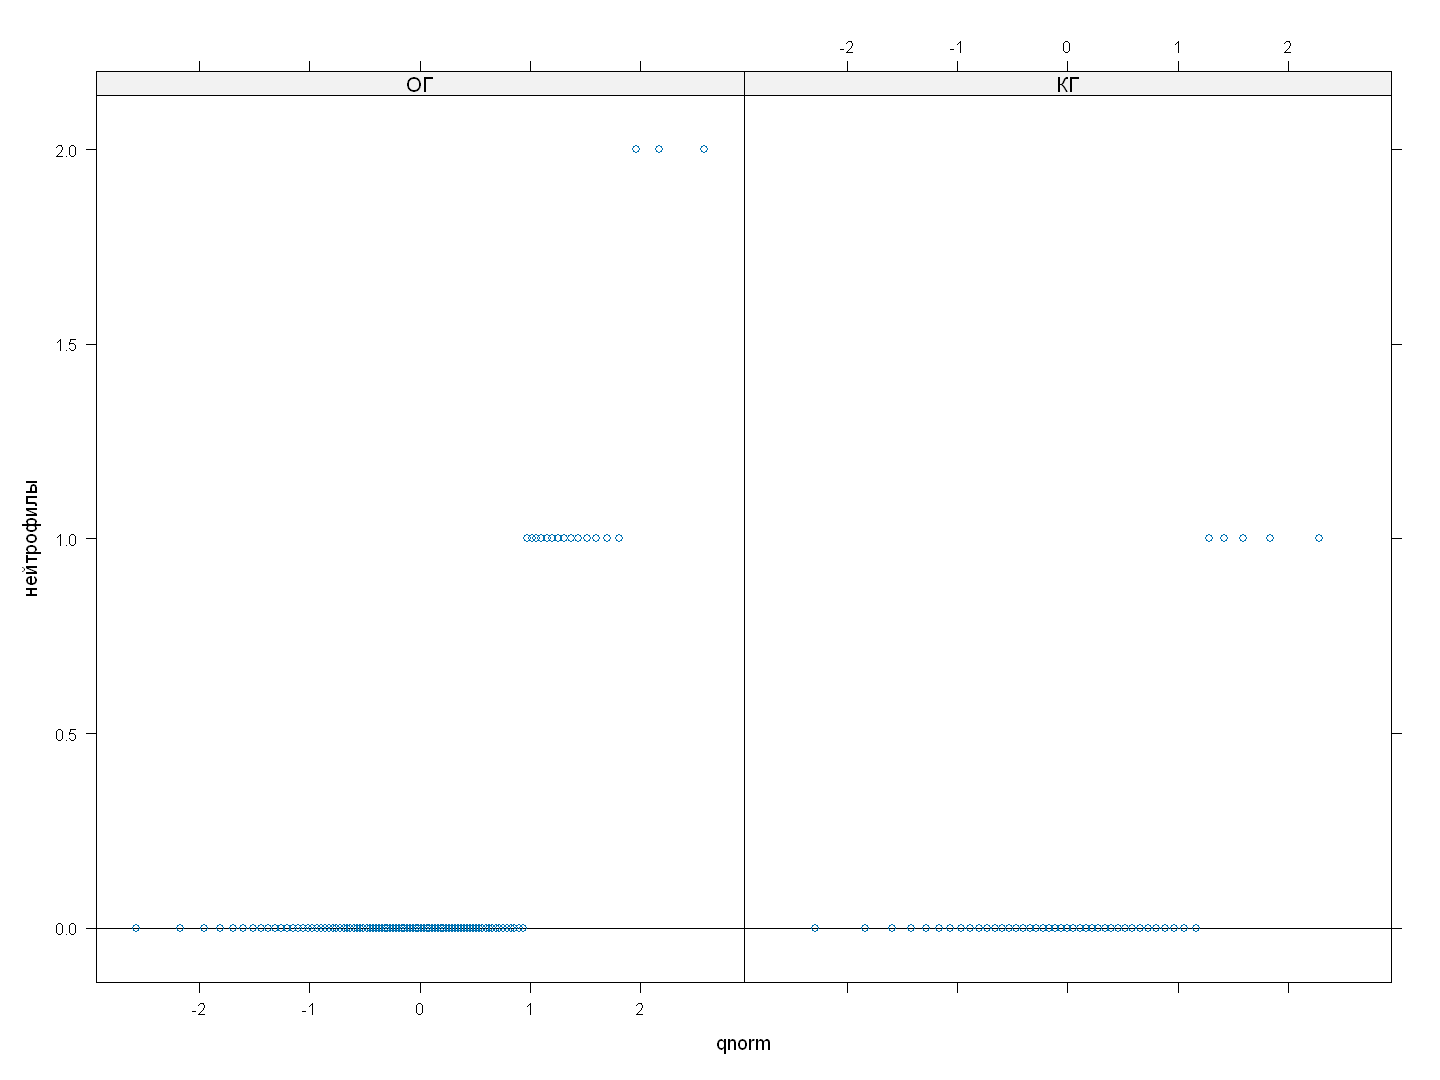

In [60]:
qqmath(~ values | parameter, panel = function(x, ...) {panel.qqmathline(x, ...); panel.qqmath(x, ...)}, ylab = parname)

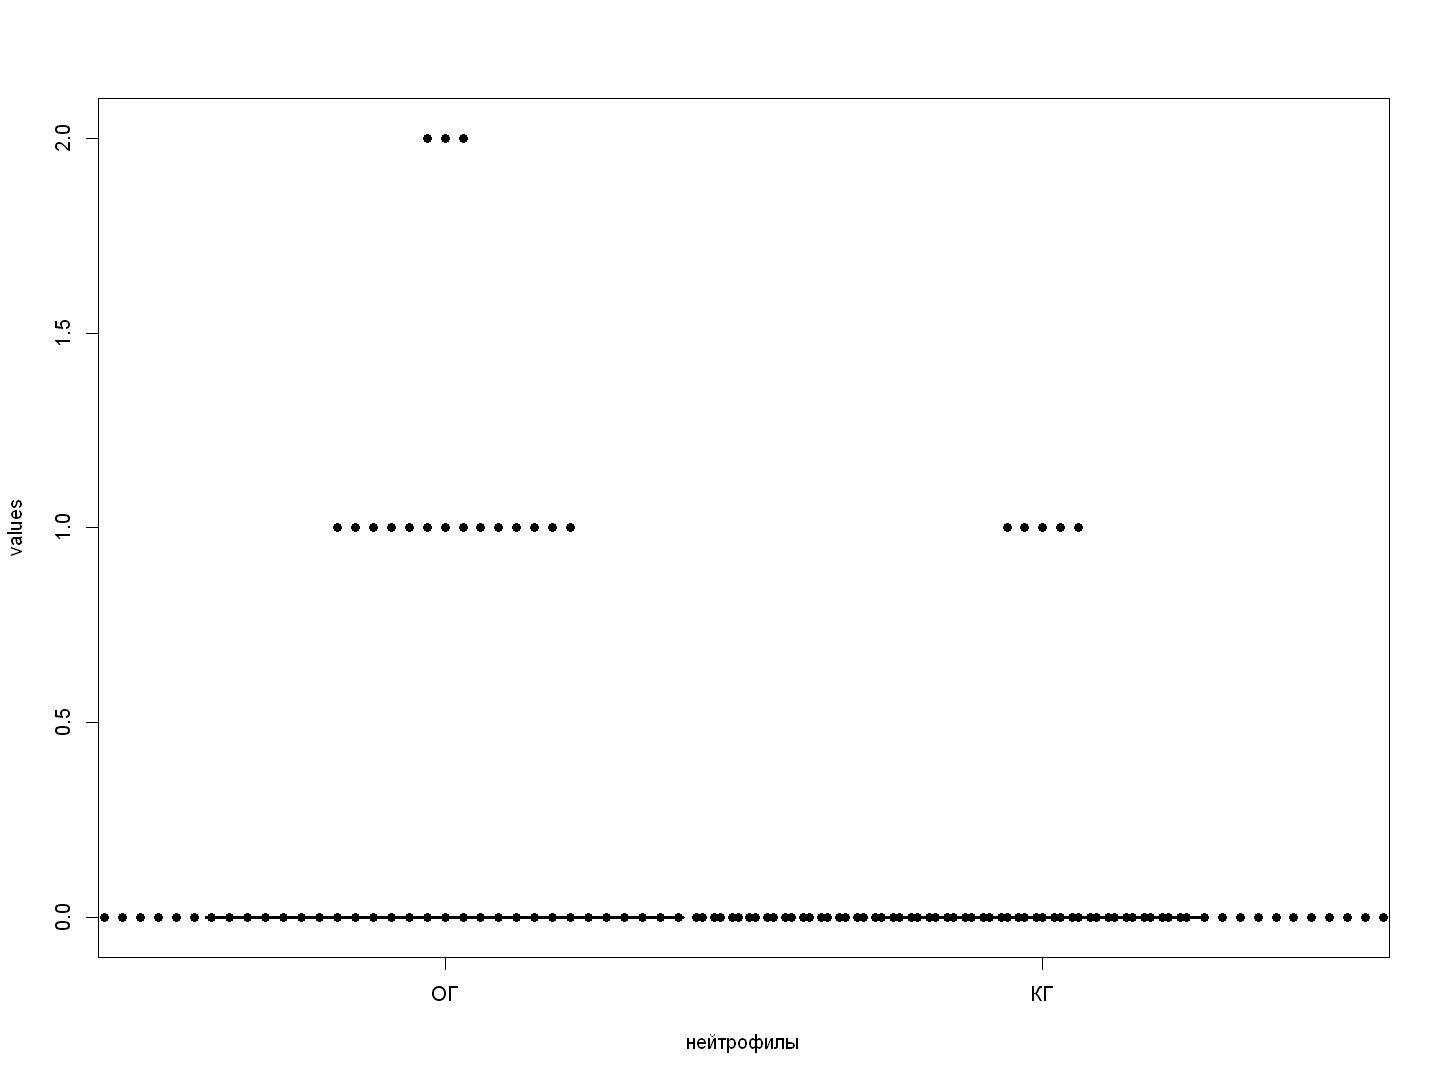

In [61]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
#abline(h= (12), lty=2, col = "grey")




### Сравнение, распределение не нормальное

In [62]:
if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    independence_test(values ~ parameter, data = lor,
                  alternative = "two.sided",
                  ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                  xtrafo = function(data) trafo(data, ordered_trafo = ff)
                  )
} else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
        for (j in (i + 1):nlevels(parameter)) {
            cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
            ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
            try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
            try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                        alternative = "two.sided",
                        distribution = "exact",
                        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                        xtrafo = function(data) trafo(data, ordered_trafo = ff)
                        )
                  )
            )
        }
    }
}


	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 2390, p-value = 0.3381
alternative hypothesis: true location shift is not equal to 0




	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ)
Z = 0.96134, p-value = 0.3364
alternative hypothesis: two.sided
